[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/antoniovfonseca/summarize-change-components/blob/main/notebooks/v3/01_agentic_ai_quest_metrics.ipynb)

# **QUEST Engine: Agentic AI for spatial analyses**

---

## Prerequisites & Setup
To run the agentic AI workflow successfully, ensure you prepare the following prerequisites before executing the notebook cells:

1. **[Google Cloud Project](https://cloud.google.com/resource-manager/docs/creating-managing-projects)**: Authenticate your environment and provide your active Google Cloud credentials to grant the spatial analyzer access to your raster map datasets stored in cloud storage buckets.

2. **[Gemini API Key](https://aistudio.google.com/app/apikey)**: Store your Gemini API key securely in your notebook secrets and retrieve it using `userdata.get("GEMINI_API_KEY")` to power the agentic reasoning loop.

3. **Dataset Configuration**: Define your target Cloud Storage bucket name containing the time series raster maps to correctly initialize the core spatial engine.

---

## Agent Capabilities & Available Products
Once the environment is set up, you can interact with the **QUEST Chat Interface** to request raw data, tables, charts, or spatial maps. Some of the analytical products you can extract from your time series raster maps include:
*   **Class Size**: Request the class area over time by asking for 'time series spatial extents', 'pixel counts', or 'stacked charts' of class sizes.
*   **Number of Changes**: Request the number of changes in 'time intervals' or 'overall' (in 'number of pixels' or 'percentage of the study area'),
*   **Trajectories**: Request the five types of trajectories in 'time intervals' or 'overall' (in 'number of pixels' or 'percentage of the study area').
*   **Transition Matrices**: Tabular data and heatmaps for 'time intervals', 'extent', 'allocation exchange', 'quantity allocation shift', 'alternation exchange', 'alternation shift', 'indirect extent', or specific intervals (e.g., 'interval 1990-2000').
*   **Change Components**: Stacked bar charts ('time intervals', 'overall', and 'per-class') detailing the Allocation and Alternation logic decomposed into Quantity, Exchange, and Shift components.
*   **Spatial Maps**: High-resolution rendered maps for the Number of Changes and Trajectories across the study area.

## 1.Environment Setup
This section loads the spatial analysis libraries and authenticates your credentials to connect the QUEST engine directly to your Google Cloud bucket.

In [ ]:
# @title 1.1 Install libraries
!pip install -q matplotlib-scalebar
!pip install -q matplotlib-map-utils

In [ ]:
# @title 1.2 Import libraries
# 1. Standard Library Imports
import os
import re
import time
from pathlib import Path
from typing import Dict

# 2. Third-Party Data and Geospatial Libraries
import numpy as np
import numba as nb
from numba import prange
import pandas as pd
import rasterio
from pyproj import Transformer, Geod
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

# 3. Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow

# 4. Google AI and Cloud Authentication
from google import genai
from google.genai import types

try:
    from google.cloud import storage
except Exception:
    storage = None

try:
    from google.colab import auth as colab_auth
    from google.colab import userdata
except ImportError:
    colab_auth = None
    userdata = None

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None


def resolve_gemini_api_key() -> str | None:
    """Resolve the Gemini API key in the same way in Colab and VS Code."""
    if load_dotenv is not None:
        load_dotenv(Path(".env"), override=False)

    key = os.getenv("GEMINI_API_KEY")
    if key:
        return key

    if userdata is not None:
        try:
            key = userdata.get("GEMINI_API_KEY")
            if key:
                return key
        except Exception:
            pass

    return None


In [ ]:
# @title 1.3 Authenticate with Google AI
os.environ["GEMINI_API_KEY"] = ""  # Replace with your actual Gemini API key

In [ ]:
# @title 1.4 User Authentication
# @markdown This cell authenticates your Google account to grant access to Google Cloud resources. It generates a temporary token strictly to read the land cover maps from the designated Cloud Storage bucket. It cannot access your personal Drive, emails, or private files. We need this direct connection so the engine can process heavy raster data in the cloud without downloading it to your machine.

# 1. Resolve API key from environment/.env/Colab secrets.
#    This fallback keeps the cell working even if Cell 5 was not rerun yet.
if "resolve_gemini_api_key" in globals():
    api_key = resolve_gemini_api_key()
else:
    api_key = os.getenv("GEMINI_API_KEY")

if api_key is not None:
    os.environ["GEMINI_API_KEY"] = api_key

# 2. Authenticate only in Colab; in VS Code use Google ADC / gcloud login.
if colab_auth is not None:
    try:
        colab_auth.authenticate_user()
    except Exception:
        pass

if "GEMINI_API_KEY" not in os.environ:
    raise RuntimeError(
        "GEMINI_API_KEY not found. "
        "In VS Code, create a .env file in the same folder as this notebook with:\n"
        "GEMINI_API_KEY=YOUR_KEY\n"
        "or run in the terminal before starting/restarting the notebook kernel:\n"
        "export GEMINI_API_KEY='YOUR_KEY'"
    )

# 3. Build the client with the explicit key so it works the same in Colab and VS Code.
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])


In [ ]:
# @title Data version
os.environ["QUEST_RASTER_PREFIX"] = "v2"

## 2. Core Architecture and Preprocessing

This section initializes the base parameters of the QUEST engine and generates the global temporal mask to ensure valid pixel tracking across the entire dataset.

In [ ]:
# @title 2.1 Core Engine Initialization
# @markdown Establishes the foundational parameters for the QUEST architecture. It maps the cloud storage paths, defines the land cover visual properties, and generates the strict global mask to ensure only valid pixels are tracked across the entire time series.


def extract_year_from_path(path: str | Path) -> int | None:
    """
    Extract a valid 4-digit year from raster file names such as:
      - vcr_v2_1986.tif
      - vcr_1986.tif
      - 1986_landsat.tif
      - landsat_1985.tif
    """
    filename = Path(str(path)).name
    stem = Path(filename).stem

    for token in reversed(stem.split("_")):
        if re.fullmatch(r"\d{4}", token):
            return int(token)

    match = re.search(r"(\d{4})", stem)
    if match is None:
        return None

    return int(match.group(1))


class QuestBase:
    """
    Core engine for spatial analysis, connecting environment to Google Cloud Storage
    and indexing annual land cover raster maps from 1985 to 2021.

    Parameters
    ----------
    bucket_name : str
        The name of the Google Cloud Storage bucket containing the raster maps.

    Examples
    --------
    >>> base = QuestBase(bucket_name="vcr-dataset")
    >>> mask = base.get_strict_temporal_mask()
    """

    def __init__(self, bucket_name: str):
        self.bucket_name = bucket_name
        self.no_data_value = 255
        self.image_paths = []
        self.searched_locations = []
        self.root_dir = ""

        # Optional local override (useful if user has a local copy).
        override_root = os.getenv("QUEST_RASTER_ROOT")
        if override_root:
            override_path = Path(override_root).expanduser()
            self.searched_locations.append(str(override_path))
            if override_path.exists():
                local_found = sorted(override_path.rglob("*.tif"))
                if local_found:
                    self.root_dir = str(override_path)
                    self.image_paths = local_found

        # Primary mode: read directly from GCS bucket blobs.
        self.gcs_listing_error = None
        if not self.image_paths:
            prefix = os.getenv("QUEST_RASTER_PREFIX", "").strip("/")
            self.searched_locations.append(
                f"gs://{self.bucket_name}/{prefix}" if prefix else f"gs://{self.bucket_name}"
            )
            if storage is None:
                self.gcs_listing_error = "google-cloud-storage package is not available"
            else:
                try:
                    gcs_client = storage.Client()
                    gcs_prefix = f"{prefix}/" if prefix else ""
                    blobs = gcs_client.list_blobs(self.bucket_name, prefix=gcs_prefix)
                    gcs_tifs = [
                        f"/vsigs/{self.bucket_name}/{blob.name}"
                        for blob in blobs
                        if blob.name.lower().endswith(".tif")
                    ]
                    if gcs_tifs:
                        self.root_dir = f"gs://{self.bucket_name}/{prefix}" if prefix else f"gs://{self.bucket_name}"
                        self.image_paths = sorted(gcs_tifs)
                except Exception as e:
                    self.gcs_listing_error = str(e)

        self.raster_by_year = {}
        for path in self.image_paths:
            year = extract_year_from_path(path)
            if year is not None:
                self.raster_by_year[year] = path

        self.output_path = f"gs://{self.bucket_name}/output"
        self.class_labels_dict = {
            1: {"name": "Trees", "color": "#228B22"},
            2: {"name": "Marsh", "color": "#A0522D"},
            3: {"name": "Beach", "color": "#DEB887"},
            4: {"name": "Water", "color": "#4A90E2"},
        }
        self.class_labels = [
            self.class_labels_dict[key]["name"]
            for key in sorted(self.class_labels_dict.keys())
        ]

    def get_strict_temporal_mask(self) -> np.ndarray:
        """
        Scans the spatial data across the time series and strips away any pixel missing data.

        Returns
        -------
        np.ndarray
            A boolean spatial mask filtering out incomplete pixel histories.

        Examples
        --------
        >>> mask = base.get_strict_temporal_mask()
        """
        raster_arrays = []
        for year in sorted(self.raster_by_year):
            path = self.raster_by_year[year]
            with rasterio.open(path) as src:
                raster_arrays.append(src.read(1))

        if not raster_arrays:
            msg = (
                "No raster files were found for the configured dataset. "
                f"Searched: {self.searched_locations}. "
                "Because your data is in GCS, set QUEST_RASTER_PREFIX (e.g., 'v2') when needed."
            )
            if self.gcs_listing_error:
                msg += f" GCS listing error: {self.gcs_listing_error}"
            raise ValueError(msg)

        global_mask = np.ones(raster_arrays[0].shape, dtype=bool)
        for arr in raster_arrays:
            global_mask &= (arr != self.no_data_value)

        return global_mask


## 3. Modules

This section contains the core computational modules of the QUEST engine. The available modules are Class Size, Number of Changes, Trajectory, Transition Matrices, Change Components, and Maps.

### 3.1 Class Size

In [ ]:
# @title 3.1.1 Class Size Processing Module
# @markdown Houses the computational methods to tally valid pixel distributions and the Matplotlib logic required by the AI agent to render on-demand charts.

class QuestClassSize(QuestBase):
    """
    Isolates the first core product of the QUEST methodology. This class inherits
    cloud connections and the strict temporal mask from the base engine, opening
    each annual raster map to extract the physical footprint of every land cover
    category. It counts only valid pixels across decades to build a precise
    historical timeline of environmental expansion or shrinkage, while integrating
    a built-in visualization engine that translates numerical dictionaries into
    dynamically scaled, sorted stacked bar charts.

    Parameters
    ----------
    bucket_name : str
        The name of the Google Cloud Storage bucket containing the raster maps.

    Examples
    --------
    >>> class_size_engine = QuestClassSize(bucket_name="vcr-dataset")
    >>> pixel_data = class_size_engine.compute_class_pixels_over_time()
    """
    def compute_class_pixels_over_time(self) -> dict:
        """
        Computes the pixel count for each land cover class over time by iterating
        chronologically through the raster archive and filtering valid pixels.

        Returns
        -------
        dict
            A nested dictionary mapping years to class pixel counts.

        Examples
        --------
        >>> pixel_data = class_size_engine.compute_class_pixels_over_time()
        """
        # 1. Retrieve the strict temporal mask
        global_mask = self.get_strict_temporal_mask()
        results = {}

        # 2. Iterate through the temporal raster stack by year
        for year in sorted(self.raster_by_year):
            path = self.raster_by_year[year]
            with rasterio.open(path) as src:
                raster_data = src.read(1)

            # 3. Filter valid pixels and calculate spatial footprint
            valid_pixels = raster_data[global_mask]
            unique_values, counts = np.unique(
                valid_pixels,
                return_counts=True,
            )
            pixel_counts = dict(
                zip(
                    unique_values,
                    counts,
                )
            )

            # 4. Map pixel counts to defined class labels
            year_summary = {}
            for class_id, info in self.class_labels_dict.items():
                class_name = info["name"]
                year_summary[class_name] = int(
                    pixel_counts.get(
                        class_id,
                        0,
                    )
                )

            results[year] = year_summary

        return results

    def plot_class_sizes(
        self,
        specific_years: list[int] = None,
    ) -> str:
        """
        Generates and displays a stacked bar chart of pixel counts per class,
        sorting categories based on net area change and applying adaptive scaling.

        Parameters
        ----------
        specific_years : list of int, optional
            A list of specific years to include in the plot. If None, uses all available years.

        Returns
        -------
        str
            Confirmation string indicating the chart was rendered on screen.

        Examples
        --------
        >>> class_size_engine.plot_class_sizes(specific_years=[1985, 2000, 2021])
        """
        data_dict = self.compute_class_pixels_over_time()

        # 1. Filter dictionary if the user requested specific years
        if specific_years:
            data_dict = {
                year: counts
                for year, counts in data_dict.items()
                if year in specific_years
            }

        df = pd.DataFrame.from_dict(
            data_dict,
            orient="index",
        )
        df.index.name = "Year"
        years_array = df.index.values

        # 2. Determine Y-axis scaling factor and label
        max_val = df.to_numpy().max()

        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000
            y_label = "Class Size (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000
            y_label = "Class Size (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000
            y_label = "Class Size (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000
            y_label = "Class Size (thousand pixels)"
        elif max_val >= 100:
            scale_factor = 100
            y_label = "Class Size (hundred pixels)"
        else:
            scale_factor = 1
            y_label = "Class Size (pixels)"

        df_scaled = df / scale_factor

        # 3. Prepare color map and sorting logic
        class_ids_plot = sorted(
            self.class_labels_dict.keys(),
        )

        color_map = {
            self.class_labels_dict[c_id]["name"]: self.class_labels_dict[c_id]["color"]
            for c_id in class_ids_plot
        }

        first_year = years_array[0]
        last_year = years_array[-1]

        net_change_per_class = (
            df_scaled.loc[last_year]
            - df_scaled.loc[first_year]
        )

        name_to_id_map = {
            v["name"]: k
            for k, v in self.class_labels_dict.items()
        }

        df_sorting = net_change_per_class.to_frame(
            name="net_change",
        )
        df_sorting["class_id"] = df_sorting.index.map(
            name_to_id_map,
        )

        classes_for_stack = list(
            df_sorting.sort_values(
                by=[
                    "net_change",
                    "class_id",
                ],
                ascending=[
                    False,
                    False,
                ],
            ).index,
        )

        classes_for_legend = list(
            reversed(classes_for_stack),
        )

        # 4. Generate the Stacked Bar Chart
        fig, ax = plt.subplots(
            figsize=(
                10,
                6,
            ),
        )

        x = np.arange(
            len(years_array),
        )
        width = 0.9
        base = np.zeros(
            len(years_array),
            dtype=float,
        )
        patches_by_class = {}

        for cls in classes_for_stack:
            if cls not in df_scaled.columns:
                continue

            values_cls = df_scaled[cls].reindex(
                years_array,
                fill_value=0.0,
            ).values

            bars = ax.bar(
                x,
                values_cls,
                bottom=base,
                width=width,
                label=cls,
                color=color_map.get(
                    cls,
                    "gray",
                ),
            )
            patches_by_class[cls] = bars[0]
            base += values_cls

        # 5. Configure Axes
        ax.set_xticks(
            x,
        )
        ax.set_xticklabels(
            years_array,
        )

        n_labels = len(years_array)

        if n_labels <= 6:
            rotation = 0
            ha = "center"
        else:
            rotation = 90
            ha = "center"

        plt.setp(
            ax.get_xticklabels(),
            rotation=rotation,
            ha=ha,
        )

        ax.tick_params(
            axis="both",
            labelsize=12,
        )
        ax.set_ylabel(
            y_label,
            fontsize=18,
        )
        ax.set_xlabel(
            "Time points",
            fontsize=18,
        )
        ax.set_title(
            "Class Size at Time Points",
            fontsize=20,
        )

        y_max_scaled = base.max() * 1.1 if base.max() > 0 else 1.0

        ax.set_ylim(
            0,
            y_max_scaled,
        )
        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=8,
                integer=True,
            ),
        )

        # 6. Add Legend
        handles = [
            patches_by_class[cls]
            for cls in classes_for_legend
            if cls in patches_by_class
        ]
        labels = [
            cls
            for cls in classes_for_legend
            if cls in patches_by_class
        ]

        ax.legend(
            handles,
            labels,
            title="Class",
            title_fontsize=16,
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            loc="center left",
            frameon=False,
            fontsize=16,
            alignment="left",
        )

        plt.tight_layout()
        plt.show()

        return (
            "Graphic rendered successfully on the user's screen.\n\n"
            "Here is a suggested description to share with the user:\n"
            "----------------------------------------------------------------------\n"
            "The graphic sorts the land cover classes based on their overall net\n"
            "size change. It places the class with the largest gain at the base\n"
            "of the stacked bar. It positions the remaining classes sequentially\n"
            "above it. Finally, it places the class experiencing the largest loss\n"
            "at the very top of the stack.\n"
            "----------------------------------------------------------------------"
        )

### 3.2 Number of changes

In [ ]:
# @title 3.2.1 Number of Changes Processing Module
# @markdown Computes the number of land cover transitions per pixel. Generates dataframes for intervals and overall metrics, alongside methods to render dynamic stacked bar charts directly on the agent interface.

class QuestNumberChanges(QuestBase):
    def compute_number_of_changes(self) -> pd.DataFrame:
        """
        Calculates the number of changes each valid pixel undergoes
        over the entire time series and groups them by interval.

        Returns
        -------
        pd.DataFrame
            A dataframe where rows represent time intervals and columns
            represent the total number of changes a pixel experienced.
        """
        # 1. Retrieve the strict temporal mask
        global_mask = self.get_strict_temporal_mask()

        # 2. Build the temporal stack of rasters
        stack_list = []
        years = []

        for path in self.image_paths:
            year = extract_year_from_path(path)
            if year is None:
                continue
            years.append(year)
            with rasterio.open(path) as src:
                stack_list.append(src.read(1))

        if not stack_list:
            raise ValueError("No valid annual rasters were found.")

        stack = np.array(stack_list)

        # 3. Apply the global mask to extract only consistently valid pixels
        valid_pixels_stack = stack[:, global_mask]

        # 4. Identify changes between consecutive years
        has_changed = (valid_pixels_stack[:-1] != valid_pixels_stack[1:])

        # 5. Calculate total lifetime changes for each valid pixel
        total_changes = has_changed.sum(axis=0)

        max_observed_changes = int(total_changes.max())
        n_intervals = has_changed.shape[0]

        counts = np.zeros((n_intervals, max_observed_changes), dtype=np.int64)

        # 6. Populate the number of changes matrix
        for t in range(n_intervals):
            pixels_changed_in_t = has_changed[t]
            totals_for_these_pixels = total_changes[pixels_changed_in_t]

            if len(totals_for_these_pixels) > 0:
                bc = np.bincount(totals_for_these_pixels)
                counts[t, : len(bc) - 1] = bc[1:]

        # 7. Format the output as a pandas DataFrame
        column_names = [str(i + 1) for i in range(max_observed_changes)]

        interval_labels = [f"{years[i]}-{years[i+1]}" for i in range(n_intervals)]

        df_intervals = pd.DataFrame(counts, index=interval_labels, columns=column_names)

        return df_intervals

    def compute_overall_changes(self) -> pd.DataFrame:
        """
        Calculates the overall number of changes across the entire study area.

        Returns
        -------
        pd.DataFrame
            A dataframe indexing the number of changes with columns for
            absolute pixel counts and percentage of the total study area.
        """
        df_intervals = self.compute_number_of_changes()
        global_mask = self.get_strict_temporal_mask()

        total_study_area_pixels = int(np.sum(global_mask))

        results = []

        for col_name in df_intervals.columns:
            n_changes = int(col_name)
            total_transitions = df_intervals[col_name].sum()

            if n_changes > 0:
                unique_pixels = total_transitions / n_changes
            else:
                unique_pixels = 0

            if total_study_area_pixels > 0:
                percentage = (unique_pixels / total_study_area_pixels) * 100.0
            else:
                percentage = 0.0

            results.append(
                {
                    "number_of_changes": n_changes,
                    "absolute_pixels": int(unique_pixels),
                    "percentage": percentage,
                }
            )

        df_overall = pd.DataFrame(results)
        df_overall.set_index("number_of_changes", inplace=True)

        return df_overall

    def plot_interval_changes(
        self,
        start_year: int = None,
        end_year: int = None,
    ) -> str:
        """
        Create a stacked bar chart showing the sequence of changes per interval,
        optionally filtered by a specific year range.

        Parameters
        ----------
        start_year : int, optional
            The starting year of the filter range.
        end_year : int, optional
            The ending year of the filter range.

        Returns
        -------
        str
            Confirmation string indicating the chart was rendered on screen.
        """
        df = self.compute_number_of_changes()

        # Filter DataFrame by custom interval range if provided
        if start_year is not None and end_year is not None:
            filtered_rows = []
            for idx in df.index:
                y_start, y_end = map(int, idx.split("-"))
                if y_start >= start_year and y_end <= end_year:
                    filtered_rows.append(idx)

            df = df.loc[filtered_rows]
            if df.empty:
                return f"No interval data found within the range {start_year}-{end_year}."

        # 1. Determine Unit Scaling
        max_val = df.sum(axis=1).max()

        if max_val >= 1_000_000_000_000:
            factor = 1_000_000_000_000.0
            suffix = " (trillion pixels)"
        elif max_val >= 1_000_000_000:
            factor = 1_000_000_000.0
            suffix = " (billion pixels)"
        elif max_val >= 1_000_000:
            factor = 1_000_000.0
            suffix = " (million pixels)"
        elif max_val >= 1_000:
            factor = 1_000.0
            suffix = " (thousand pixels)"
        else:
            factor = 1.0
            suffix = ""

        df_scaled = df / factor

        fig, ax = plt.subplots(figsize=(14, 6))

        n_cols = len(df.columns)
        cmap = plt.cm.viridis_r

        if n_cols > 1:
            colors = [cmap(i / (n_cols - 1)) for i in range(n_cols)]
        else:
            colors = [cmap(0.5)]

        bottom = pd.Series(0.0, index=df_scaled.index)

        for i, col in reversed(list(enumerate(df.columns))):
            vals = df_scaled[col]

            if vals.sum() == 0:
                label_txt = "_nolegend_"
            else:
                label_txt = f"{col}"

            ax.bar(
                df_scaled.index,
                vals,
                bottom=bottom,
                label=label_txt,
                color=colors[i],
                edgecolor="none",
                linewidth=0.5,
                width=0.9,
            )
            bottom += vals

        y_label_text = f"Change{suffix}"
        ax.set_ylabel(y_label_text, fontsize=18)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))

        title_suffix = f" ({start_year}-{end_year})" if start_year and end_year else ""
        ax.set_title(f"Number of Changes during Time Intervals{title_suffix}", fontsize=20, pad=15)

        labels = ax.get_xticklabels()
        n_labels = len(labels)

        if n_labels <= 6:
            rotation = 0
            ha = "center"
        elif n_labels <= 12:
            rotation = 45
            ha = "right"
        else:
            rotation = 90
            ha = "center"

        plt.setp(labels, rotation=rotation, ha=ha, fontsize=18)
        ax.tick_params(axis="y", rotation=0, labelsize=18)

        handles, labels_leg = ax.get_legend_handles_labels()
        leg = ax.legend(
            handles[::-1],
            labels_leg[::-1],
            title="Changes",
            title_fontsize=16,
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            frameon=False,
            fontsize=16,
        )

        for patch in leg.get_patches():
            patch.set_linewidth(0)

        plt.tight_layout()
        plt.show()

        return (
            "The graphic shows the number of changes per time interval. The stacked\n"
            "bars represent the total number of changes those specific pixels\n"
            "experienced over the entire time series."
        )

    def plot_overall_changes(
        self,
        metric: str = "percentage",
    ) -> str:
        """
        Generates a stacked bar chart of the overall number of changes.

        Parameters
        ----------
        metric : str, optional
            The metric for the Y-axis, either 'percentage' or 'pixels'.
            Default is 'percentage'.

        Returns
        -------
        str
            Confirmation string indicating the chart was rendered.
        """
        df_overall = self.compute_overall_changes()

        if metric == "percentage":
            plot_values = df_overall["percentage"].to_dict()
        else:
            plot_values = df_overall["absolute_pixels"].to_dict()

        active_changes = [k for k, v in plot_values.items() if v > 0]

        if not active_changes:
            active_changes = list(plot_values.keys())

        n_colors = len(active_changes)
        cmap = plt.cm.viridis_r

        sorted_changes_desc = sorted(active_changes, reverse=True)

        colors = {
            n: cmap(i / (n_colors - 1)) if n_colors > 1 else cmap(0.5)
            for i, n in enumerate(sorted(active_changes))
        }

        fig, ax = plt.subplots(figsize=(6, 6))

        bottom = 0.0
        for n_change in sorted_changes_desc:
            val = plot_values[n_change]
            if val > 0:
                ax.bar(0, val, bottom=bottom, color=colors[n_change], width=0.4, edgecolor="none")
                bottom += val

        if metric == "percentage":
            ax.set_ylabel("Change (% of study area)", fontsize=16)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=10))
        else:
            max_val = bottom

            if max_val >= 1_000_000_000_000:
                scale_factor = 1_000_000_000_000
                y_label = "Change (trillion pixels)"
            elif max_val >= 1_000_000_000:
                scale_factor = 1_000_000_000
                y_label = "Change (billion pixels)"
            elif max_val >= 1_000_000:
                scale_factor = 1_000_000
                y_label = "Change (million pixels)"
            elif max_val >= 1_000:
                scale_factor = 1_000
                y_label = "Change (thousand pixels)"
            elif max_val >= 100:
                scale_factor = 100
                y_label = "Change (hundred pixels)"
            else:
                scale_factor = 1
                y_label = "Change (pixels)"

            ax.set_ylabel(y_label, fontsize=16)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x / scale_factor:g}"))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

        ax.set_title("Number of Changes Overall", fontsize=18, pad=15)

        for spine in ["top", "right", "bottom", "left"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color("black")
            ax.spines[spine].set_linewidth(0.5)

        ax.tick_params(axis="y", which="major", labelsize=18)
        ax.set_xticks([])

        max_y = bottom * 1.05 if bottom > 0 else 1.0
        ax.set_ylim(0, max_y)

        legend_elements = []

        for n in sorted(active_changes):
            legend_elements.append(
                plt.Rectangle((0, 0), 1, 1, fc=colors[n], label=str(n))
            )

        ax.legend(
            handles=legend_elements,
            title="Changes",
            title_fontsize=16,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            fontsize=14,
            frameon=False,
        )

        fig.subplots_adjust(left=0.15, right=0.75, bottom=0.1, top=0.9)

        plt.show()

        return (
            "The graphic shows the total changes in the time series, summing\n"
            "all the changes in the time intervals."
        )


class QuestCustomExtentChanges(QuestNumberChanges):
    def __init__(self, bucket_name: str, start_year: int, end_year: int):
        super().__init__(bucket_name)
        self.image_paths = [
            path for path in self.image_paths
            if start_year <= extract_year_from_path(path) <= end_year
        ]


### 3.3 Trajectory Analysis

In [ ]:
# @title 3.3.1 Trajectory Processing Module
# @markdown Computes pixel trajectories based on land cover persistence and transitions, fully vectorized using the strict global temporal mask, and includes plotting methods.

class QuestTrajectory(QuestBase):
    def _compute_trajectories(
        self,
    ) -> tuple[np.ndarray, np.ndarray, list[int]]:
        """
        Internal method to load the strict stack and compute trajectory
        classes (1 to 5) using pure NumPy vectorization.

        Returns
        -------
        tuple[np.ndarray, np.ndarray, list[int]]
            A tuple containing the valid temporal stack, the 1D array of
            trajectory classes for valid pixels, and the list of years.
        """
        global_mask = self.get_strict_temporal_mask()

        stack_list = []
        years = []

        for path in self.image_paths:
            year = extract_year_from_path(path)
            if year is None:
                continue
            years.append(year)
            with rasterio.open(path) as src:
                stack_list.append(src.read(1))

        if not stack_list:
            raise ValueError("No valid annual rasters were found.")

        stack = np.array(stack_list)
        valid_stack = stack[:, global_mask]

        start = valid_stack[0]
        end = valid_stack[-1]

        traj = np.zeros(valid_stack.shape[1], dtype=np.uint8)

        mask_same_ends = (start == end)
        has_change = (valid_stack != start).any(axis=0)

        traj[mask_same_ends & ~has_change] = 1
        traj[mask_same_ends & has_change] = 2

        mask_diff_ends = (start != end)

        direct_trans = ((valid_stack[:-1] == start) & (valid_stack[1:] == end)).any(axis=0)

        traj[mask_diff_ends & ~direct_trans] = 5

        path_changes = (valid_stack[:-1] != valid_stack[1:]).sum(axis=0)

        traj[mask_diff_ends & direct_trans & (path_changes == 1)] = 3
        traj[mask_diff_ends & direct_trans & (path_changes > 1)] = 4

        return valid_stack, traj, years

    def compute_trajectory_intervals(self) -> pd.DataFrame:
        """
        Calculates the number of trajectory changes in each time interval.

        Returns
        -------
        pd.DataFrame
            A dataframe with time intervals as index and trajectory
            classes (2, 3, 4, 5) as columns.
        """
        valid_stack, traj, years = self._compute_trajectories()
        n_intervals = valid_stack.shape[0] - 1

        counts = np.zeros((n_intervals, 4), dtype=np.int64)
        traj_classes = np.array([2, 3, 4, 5])

        for t in range(n_intervals):
            changed_pixels_t = (valid_stack[t] != valid_stack[t + 1])
            traj_changed = traj[changed_pixels_t]

            for col_idx, c in enumerate(traj_classes):
                counts[t, col_idx] = (traj_changed == c).sum()

        interval_labels = [f"{years[i]}-{years[i+1]}" for i in range(n_intervals)]

        df_intervals = pd.DataFrame(counts, index=interval_labels, columns=traj_classes)
        df_intervals.index.name = "Interval"
        df_intervals.columns.name = "Trajectory_Class"

        return df_intervals

    def compute_overall_trajectories(self) -> pd.DataFrame:
        """
        Calculates the total unique pixels per trajectory class across the
        entire study area.

        Returns
        -------
        pd.DataFrame
            A dataframe indexing the trajectory class (2, 3, 4, 5) with
            columns for absolute pixel counts and percentage.
        """
        _, traj, _ = self._compute_trajectories()
        global_mask = self.get_strict_temporal_mask()

        total_study_area_pixels = int(np.sum(global_mask))

        results = []
        traj_classes = [2, 3, 4, 5]

        for c in traj_classes:
            unique_pixels = (traj == c).sum()

            if total_study_area_pixels > 0:
                percentage = (unique_pixels / total_study_area_pixels) * 100.0
            else:
                percentage = 0.0

            results.append(
                {
                    "Trajectory_Class": c,
                    "absolute_pixels": int(unique_pixels),
                    "percentage": percentage,
                }
            )

        df_overall = pd.DataFrame(results)
        df_overall.set_index("Trajectory_Class", inplace=True)

        return df_overall

    def plot_trajectory_intervals(
        self,
        start_year: int = None,
        end_year: int = None,
    ) -> str:
        """
        Create a stacked bar chart for trajectory contributions per interval,
        optionally filtered by a specific year range.

        Parameters
        ----------
        start_year : int, optional
            The starting year of the filter range.
        end_year : int, optional
            The ending year of the filter range.

        Returns
        -------
        str
            Confirmation string indicating the chart was rendered on screen.
        """
        df = self.compute_trajectory_intervals()
        df.columns = df.columns.astype(int)

        if start_year is not None and end_year is not None:
            filtered_rows = []
            for idx in df.index:
                y_start, y_end = map(int, idx.split("-"))
                if y_start >= start_year and y_end <= end_year:
                    filtered_rows.append(idx)

            df = df.loc[filtered_rows]
            if df.empty:
                return f"No interval data found within the range {start_year}-{end_year}."

        max_val = df.sum(axis=1).max()

        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000.0
            y_label = "Change (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000.0
            y_label = "Change (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000.0
            y_label = "Change (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000.0
            y_label = "Change (thousand pixels)"
        else:
            scale_factor = 1.0
            y_label = "Change (pixels)"

        df_scaled = df / scale_factor

        colors = {
            2: "#990033",
            3: "#FDE724",
            4: "#ff9900",
            5: "#000066",
        }

        stack_order = [5, 4, 3, 2]

        fig, ax = plt.subplots(figsize=(12, 6))

        bottom = pd.Series(0.0, index=df_scaled.index)

        for traj_id in stack_order:
            if traj_id in df_scaled.columns:
                values = df_scaled[traj_id]
                ax.bar(df_scaled.index, values, label=str(traj_id), bottom=bottom, color=colors[traj_id], edgecolor="none", width=0.9)
                bottom += values

        ax.set_ylabel(y_label, fontsize=18)

        title_suffix = f" ({start_year}-{end_year})" if start_year and end_year else ""
        ax.set_title(f"Trajectories during Time Intervals{title_suffix}", fontsize=20, pad=15)

        labels = ax.get_xticklabels()
        n_labels = len(labels)

        if n_labels <= 6:
            rotation = 0
            ha = "center"
        elif n_labels <= 12:
            rotation = 45
            ha = "right"
        else:
            rotation = 90
            ha = "center"

        plt.setp(labels, rotation=rotation, ha=ha, fontsize=18)
        ax.tick_params(axis="y", labelsize=18)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))

        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(True)

        handles, labels_leg = ax.get_legend_handles_labels()
        if handles:
            legend_order_map = {"2": 0, "3": 1, "4": 2, "5": 3}
            sorted_pairs = sorted(zip(handles, labels_leg), key=lambda x: legend_order_map.get(x[1], 99))
            sorted_handles, sorted_labels = zip(*sorted_pairs)

            ax.legend(
                sorted_handles,
                sorted_labels,
                loc="center left",
                bbox_to_anchor=(1.01, 0.5),
                title="Trajectory",
                title_fontsize=14,
                alignment="left",
                fontsize=14,
                frameon=False,
            )

        plt.tight_layout()
        plt.show()

        return "Trajectory interval chart rendered successfully."

    def plot_overall_trajectories(
        self,
        metric: str = "percentage",
    ) -> str:
        """
        Generates a stacked bar chart of the overall trajectory distributions.

        Parameters
        ----------
        metric : str, optional
            The metric for the Y-axis, either 'percentage' or 'pixels'.
            Default is 'percentage'.

        Returns
        -------
        str
            Confirmation string indicating the chart was rendered.
        """
        df_overall = self.compute_overall_trajectories()

        if metric == "percentage":
            plot_values = df_overall["percentage"].to_dict()
        else:
            plot_values = df_overall["absolute_pixels"].to_dict()

        ordered_trajs = [5, 4, 3, 2]

        colors = {
            2: "#990033",
            3: "#FDE724",
            4: "#ff9900",
            5: "#000066",
        }

        fig, ax = plt.subplots(figsize=(6, 6))

        bottom = 0.0
        for traj in ordered_trajs:
            val = plot_values.get(traj, 0.0)
            ax.bar(0, val, bottom=bottom, color=colors[traj], width=0.4, edgecolor="none")
            bottom += val

        if metric == "percentage":
            ax.set_ylabel("Change (% of study area)", fontsize=16)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=10))
        else:
            max_val = bottom

            if max_val >= 1_000_000_000_000:
                scale_factor = 1_000_000_000_000
                y_label = "Change (trillion pixels)"
            elif max_val >= 1_000_000_000:
                scale_factor = 1_000_000_000
                y_label = "Change (billion pixels)"
            elif max_val >= 1_000_000:
                scale_factor = 1_000_000
                y_label = "Change (million pixels)"
            elif max_val >= 1_000:
                scale_factor = 1_000
                y_label = "Change (thousand pixels)"
            elif max_val >= 100:
                scale_factor = 100
                y_label = "Change (hundred pixels)"
            else:
                scale_factor = 1
                y_label = "Change (pixels)"

            ax.set_ylabel(y_label, fontsize=16)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x / scale_factor:g}"))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

        ax.set_title("Trajectories Overall", fontsize=18, pad=15)

        for spine in ["top", "right", "bottom", "left"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color("black")
            ax.spines[spine].set_linewidth(0.5)

        ax.tick_params(axis="y", which="major", labelsize=18)
        ax.set_xticks([])
        ax.set_ylim(0, bottom * 1.05 if bottom > 0 else 1.0)

        legend_elements = [
            plt.Rectangle((0, 0), 1, 1, fc=colors[2], label="2"),
            plt.Rectangle((0, 0), 1, 1, fc=colors[3], label="3"),
            plt.Rectangle((0, 0), 1, 1, fc=colors[4], label="4"),
            plt.Rectangle((0, 0), 1, 1, fc=colors[5], label="5"),
        ]

        ax.legend(
            handles=legend_elements,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            title="Trajectory",
            title_fontsize=14,
            alignment="left",
            fontsize=14,
            frameon=False,
        )

        fig.subplots_adjust(left=0.15, right=0.75, bottom=0.1, top=0.9)

        plt.show()

        return f"Overall trajectory chart ({metric}) rendered successfully."


class QuestCustomExtentTrajectory(QuestTrajectory):
    def __init__(
        self,
        bucket_name: str,
        start_year: int,
        end_year: int,
    ):
        super().__init__(bucket_name)
        self.image_paths = [
            path for path in self.image_paths
            if start_year <= extract_year_from_path(path) <= end_year
        ]


### 3.4 Transition matrices

In [ ]:
# @title 3.4.1 Transition Matrix Processing Module
# @markdown Computes transition matrices and components using dynamic chunked NumPy vectorization over the strict global temporal mask.

class QuestTransition(QuestBase):
    def compute_transition_matrices(
        self,
    ) -> dict[str, pd.DataFrame]:
        """
        Compute interval and aggregated transition matrices.

        Returns
        -------
        dict[str, pd.DataFrame]
            Dictionary containing the computed matrices as DataFrames.
        """
        # 1. Get the strict global temporal mask to exclude nodata
        global_mask = self.get_strict_temporal_mask()

        # 2. Load rasters and build the valid temporal stack
        stack_list = []
        self.years = []

        for path in self.image_paths:
            year = extract_year_from_path(path)
            if year is None:
                continue
            self.years.append(year)
            with rasterio.open(path) as src:
                stack_list.append(src.read(1))

        if not stack_list:
            raise ValueError("No valid annual rasters were found.")

        stack = np.array(stack_list)
        valid_stack = stack[:, global_mask]

        # 3. Identify all unique classes across the timeline
        all_classes = np.unique(valid_stack).astype(int)
        n = len(all_classes)

        # 4. Map class values to contiguous zero-based indices
        class_to_idx = {cls: i for i, cls in enumerate(all_classes)}

        mapped_stack = np.zeros_like(valid_stack)
        for cls, idx in class_to_idx.items():
            mapped_stack[valid_stack == cls] = idx

        n_times, n_pixels = mapped_stack.shape

        # 5. Initialize global accumulation matrices
        mat_time_intervals = np.zeros((n, n), dtype=np.float64)
        mat_extent = np.zeros((n, n), dtype=np.float64)
        mat_alt_exchange = np.zeros((n, n), dtype=np.float64)
        mat_alt_shift = np.zeros((n, n), dtype=np.float64)
        mat_indirect_extent = np.zeros((n, n), dtype=np.float64)

        interval_matrices = {
            f"{self.years[t]}-{self.years[t+1]}": np.zeros((n, n), dtype=np.float64)
            for t in range(n_times - 1)
        }

        # 6. Dynamically calculate chunk size to prevent memory overflow (OOM)
        # Allocate exactly 1 GB limit for 3D matrix broadcasting.
        # Cost per pixel = 10 simultaneous matrices * 8 bytes (float64) * n squared.
        safe_memory_limit_bytes = 1024 ** 3
        bytes_per_pixel = 80 * (n ** 2)

        # Ensure a minimum chunk of 10,000 pixels to maintain vectorization speed
        chunk_size = max(10_000, int(safe_memory_limit_bytes / bytes_per_pixel))

        # 7. Process pixel trajectories in vectorized chunks
        for start_idx in range(0, n_pixels, chunk_size):
            end_idx = min(start_idx + chunk_size, n_pixels)
            chunk = mapped_stack[:, start_idx:end_idx]
            c_size = chunk.shape[1]

            # 7.1. Compute Matrix M_r (Transition Matrix per chunk)
            m_r = np.zeros((c_size, n, n), dtype=np.float64)

            for t in range(n_times - 1):
                s_t = chunk[t]
                e_t = chunk[t + 1]

                m_r[np.arange(c_size), s_t, e_t] += 1

                for i in range(n):
                    for j in range(n):
                        mask_trans = (s_t == i) & (e_t == j)
                        interval_matrices[f"{self.years[t]}-{self.years[t+1]}"][i, j] += mask_trans.sum()

            # 7.2. Compute Matrix E_r (Extent Matrix per chunk)
            e_r = np.zeros((c_size, n, n), dtype=np.float64)
            start_val = chunk[0]
            end_val = chunk[-1]
            e_r[np.arange(c_size), start_val, end_val] = 1

            diff_m_e = m_r - e_r
            diff_m_e_t = diff_m_e.transpose(0, 2, 1)

            # 7.3. Compute Matrix X_r (Alternation Exchange per chunk)
            x_r = np.maximum(0.0, np.minimum(diff_m_e, diff_m_e_t))

            # 7.4. Compute Matrix S_r (Alternation Shift per chunk)
            s_r = np.maximum(0.0, m_r - x_r - e_r)

            # 7.5. Compute Matrix U_r (Indirect Extent per chunk)
            u_r = e_r + x_r + s_r - m_r

            # 7.6. Accumulate chunk results into global matrices
            mat_time_intervals += m_r.sum(axis=0)
            mat_extent += e_r.sum(axis=0)
            mat_alt_exchange += x_r.sum(axis=0)
            mat_alt_shift += s_r.sum(axis=0)
            mat_indirect_extent += u_r.sum(axis=0)

        # 8. Post-Loop Calculations for Allocation Components (C and Q)
        mat_alloc_exchange = np.minimum(mat_extent, mat_extent.T)
        mat_qty_alloc_shift = mat_extent - mat_alloc_exchange

        # 9. Format output matrices into Pandas DataFrames
        output_dfs = {}

        output_dfs["time_intervals"] = pd.DataFrame(mat_time_intervals, index=all_classes, columns=all_classes)
        output_dfs["extent"] = pd.DataFrame(mat_extent, index=all_classes, columns=all_classes)
        output_dfs["allocation_exchange"] = pd.DataFrame(mat_alloc_exchange, index=all_classes, columns=all_classes)
        output_dfs["quantity_allocation_shift"] = pd.DataFrame(mat_qty_alloc_shift, index=all_classes, columns=all_classes)
        output_dfs["alternation_exchange"] = pd.DataFrame(mat_alt_exchange, index=all_classes, columns=all_classes)
        output_dfs["alternation_shift"] = pd.DataFrame(mat_alt_shift, index=all_classes, columns=all_classes)
        output_dfs["indirect_extent"] = pd.DataFrame(mat_indirect_extent, index=all_classes, columns=all_classes)

        for interval_name, mat in interval_matrices.items():
            output_dfs[f"interval_{interval_name}"] = pd.DataFrame(mat, index=all_classes, columns=all_classes)

        return output_dfs

    def _compute_net_change(
        self,
        df_sum: pd.DataFrame,
    ) -> pd.Series:
        """
        Compute net change per class from the time_intervals matrix.

        Parameters
        ----------
        df_sum : pd.DataFrame
            Square transition matrix representing total transitions over
            the full time span.

        Returns
        -------
        pd.Series
            Net change for each class (gains minus losses).

        Examples
        --------
        >>> gains_losses = self._compute_net_change(df_sum=matrix)
        """
        m_vals = df_sum.values.astype(float).copy()
        np.fill_diagonal(m_vals, 0.0)
        gains = m_vals.sum(axis=0)
        losses = m_vals.sum(axis=1)
        net_change = gains - losses
        return pd.Series(net_change, index=df_sum.index)

    def _reorder_matrices(
        self,
        matrices_dict: dict[str, pd.DataFrame],
    ) -> dict[str, pd.DataFrame]:
        """
        Reorder rows and columns of all matrices using net change.

        Parameters
        ----------
        matrices_dict : dict[str, pd.DataFrame]
            Dictionary containing all loaded DataFrames.

        Returns
        -------
        dict[str, pd.DataFrame]
            Dictionary with all input DataFrames reindexed based on net change.

        Examples
        --------
        >>> reordered_mats = self._reorder_matrices(matrices_dict=mats)
        """
        net_change = self._compute_net_change(df_sum=matrices_dict["time_intervals"])
        order_labels = net_change.sort_values(ascending=True).index.tolist()

        reordered = {}
        for k, df in matrices_dict.items():
            reordered[k] = df.reindex(index=order_labels, columns=order_labels)

        return reordered

    @staticmethod
    def _annotate_heatmap(
        ax: plt.Axes,
        m_vals: np.ndarray,
        fontsize: int = 11,
        show_diagonal: bool = True,
        equalize_diagonal_font: bool = False,
    ) -> None:
        """
        Annotate a heatmap with integer cell values using a standardized font size and adaptive text contrast.
        """
        if m_vals.size == 0:
            return

        rows, cols = m_vals.shape
        max_val_str = str(int(np.nanmax(np.abs(m_vals))))
        max_len = len(max_val_str)
        uniform_fontsize = 9.5 if max_len > 6 else 11

        m_off = m_vals.copy()
        np.fill_diagonal(m_off, np.nan)
        max_off = np.nanmax(m_off) if np.any(np.isfinite(m_off)) else 1.0
        threshold = 0.5 * max_off

        for i in range(rows):
            for j in range(cols):
                val = float(m_vals[i, j])

                if i == j:
                    if not show_diagonal:
                        continue
                    color = "white"
                else:
                    if val >= threshold and val > 0:
                        color = "white"
                    else:
                        color = "black"

                txt = f"{int(round(val))}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=uniform_fontsize, color=color, clip_on=True)

    def plot_matrix_heatmap(
        self,
        matrix_key: str,
        class_labels_dict: dict = None,
    ) -> str:
        """
        Plot a square transition matrix as a heatmap.
        """
        matrices = self.compute_transition_matrices()
        matrices = self._reorder_matrices(matrices_dict=matrices)

        if matrix_key not in matrices:
            return f"Matrix '{matrix_key}' not found. Available keys: {list(matrices.keys())}"

        df = matrices[matrix_key]

        if class_labels_dict is None:
            class_labels_dict = {}

        start_year = self.years[0]
        end_year = self.years[-1]

        matrix_meta = {
            "time_intervals": ("Time Intervals", "flow"),
            "extent": ("Extent", "stock"),
            "allocation_exchange": ("Allocation Exchange", "stock"),
            "quantity_allocation_shift": ("Quantity & Allocation Shift", "stock"),
            "alternation_exchange": ("Alternation Exchange", "flow"),
            "alternation_shift": ("Alternation Shift", "flow"),
            "indirect_extent": ("Indirect", "stock"),
        }

        if matrix_key.startswith("interval_"):
            title_part = "Time Interval"
            m_type = "flow"
            interval_str = matrix_key.replace("interval_", "")
            full_title = f"{title_part} {interval_str}"
        else:
            title_part, m_type = matrix_meta.get(matrix_key, ("Custom Matrix", "flow"))
            label_suffix = "..." if m_type == "flow" else "-"
            full_title = f"{title_part} {start_year}{label_suffix}{end_year}"

        is_flow = (m_type == "flow")
        xlabel = "To class" if is_flow else "End class"
        ylabel = "From class" if is_flow else "Begin class"
        cbar_label = "Transitions" if is_flow else "Pixels"
        is_extent = (matrix_key == "extent")

        labels = list(df.index)
        tick_names = [self.class_labels_dict.get(int(lab), {}).get("name", str(lab)) for lab in labels]

        matrix_values = df.values.astype(float)

        matrix_scale = matrix_values.copy()
        np.fill_diagonal(matrix_scale, 0.0)
        finite_vals_raw = matrix_scale[np.isfinite(matrix_scale)]

        max_abs = float(np.nanmax(np.abs(finite_vals_raw))) if finite_vals_raw.size > 0 else 0.0

        if max_abs >= 1_000_000_000_000:
            factor = 1_000_000_000_000.0
            suffix = "T"
        elif max_abs >= 1_000_000_000:
            factor = 1_000_000_000.0
            suffix = "B"
        elif max_abs >= 1_000_000:
            factor = 1_000_000.0
            suffix = "M"
        elif max_abs >= 1_000:
            factor = 1_000.0
            suffix = "k"
        else:
            factor = 1.0
            suffix = ""

        matrix_display_values = matrix_values / factor

        matrix_scale_disp = matrix_display_values.copy()
        np.fill_diagonal(matrix_scale_disp, 0.0)
        finite_vals_disp = matrix_scale_disp[np.isfinite(matrix_scale_disp)]

        has_negative = False
        vmin_eff, vmax_eff = 0.0, 1.0

        if finite_vals_disp.size > 0:
            has_negative = float(np.nanmin(finite_vals_disp)) < 0.0
            min_val = float(np.nanmin(finite_vals_disp))
            max_val = float(np.nanmax(finite_vals_disp))

            if has_negative:
                vmin_eff, vmax_eff = min_val, max_val
            else:
                vmin_eff = 0.0
                vmax_eff = float(max_val)

            if vmin_eff == vmax_eff:
                vmax_eff += 1.0

        if vmax_eff <= 10:
            ceiling_scaled = np.ceil(vmax_eff)
        else:
            ceiling_scaled = np.ceil(vmax_eff / 5.0) * 5.0
        vmax_eff = ceiling_scaled

        nrows, ncols = df.shape
        figsize = (max(7.0, 1.2 * ncols), max(6.0, 1.2 * nrows))

        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        cmap_neg = mcolors.LinearSegmentedColormap.from_list("CustomBlues", ["#08306b", "#b3e0ff"])

        if has_negative:
            matrix_pos = np.ma.masked_less_equal(matrix_display_values, 0.0)
            norm_pos = mcolors.Normalize(vmin=0.0, vmax=vmax_eff)
            ax.imshow(matrix_pos, aspect="equal", cmap=plt.cm.YlOrRd, norm=norm_pos)

            matrix_neg = np.ma.masked_where(matrix_display_values >= 0.0, matrix_display_values)
            norm_neg = mcolors.Normalize(vmin=vmin_eff, vmax=0.0)
            ax.imshow(matrix_neg, aspect="equal", cmap=cmap_neg, norm=norm_neg)
        else:
            matrix_pos = np.ma.masked_equal(matrix_display_values, 0.0)
            norm_pos = mcolors.Normalize(vmin=vmin_eff, vmax=vmax_eff)
            ax.imshow(matrix_pos, aspect="equal", cmap=plt.cm.YlOrRd, norm=norm_pos)

        diag_mask = np.eye(nrows, dtype=bool)
        matrix_diag = np.ma.masked_where(~diag_mask, np.ones_like(matrix_display_values))
        ax.imshow(matrix_diag, aspect="equal", cmap=mcolors.ListedColormap(["black"]), vmin=0.0, vmax=1.0)

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(tick_names, rotation=90, fontsize=12)
        ax.set_yticklabels(tick_names, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_title(full_title, fontsize=18)

        n_bar = 256
        vals = np.linspace(vmin_eff, vmax_eff, n_bar)
        colors_bar = []

        for v in vals:
            if has_negative and v < 0.0:
                t = (v - vmin_eff) / (0.0 - vmin_eff) if vmin_eff < 0 else 0
                colors_bar.append(cmap_neg(t))
            elif v == 0:
                colors_bar.append((1.0, 1.0, 1.0, 1.0))
            else:
                t = max(0.0, v) / vmax_eff if vmax_eff > 0.0 else 0.0
                colors_bar.append(plt.cm.YlOrRd(t))

        cmap_bar = mcolors.ListedColormap(colors_bar)
        norm_bar = mcolors.Normalize(vmin=vmin_eff, vmax=vmax_eff)

        scalar_mappable = plt.cm.ScalarMappable(cmap=cmap_bar, norm=norm_bar)
        scalar_mappable.set_array([])

        cbar = fig.colorbar(scalar_mappable, ax=ax, fraction=0.025, pad=0.02)

        cbar.locator = mticker.MaxNLocator(nbins=4, integer=True, prune="both")
        cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x)}")
        cbar.update_ticks()

        mapping = {
            "": cbar_label,
            "k": f"{cbar_label} (thousands)",
            "M": f"{cbar_label} (millions)",
            "B": f"{cbar_label} (billions)",
            "T": f"{cbar_label} (trillions)",
        }

        cbar.set_label(mapping.get(suffix, cbar_label), fontsize=12)

        plt.show()
        return f"Heatmap for {matrix_key} rendered successfully."


### 3.5 Change Components

In [ ]:
# @title 3.5.1 Change Components Processing Module
# @markdown Houses the computational engine to decompose transition matrices into Quantity, Exchange, and Shift components, structuring the results into a standardized master table.

class QuestChangeComponents(QuestTransition):
    """
    Calculates and organizes change components from transition matrices,
    differentiating strictly between Allocation and Alternation logic.
    """

    def _calculate_matrix_components(
        self,
        transition_matrix: np.ndarray,
        force_component: str = None,
    ) -> list[dict]:
        """
        Decompose a transition matrix into gain, loss, exchange, and shift.

        Parameters
        ----------
        transition_matrix : np.ndarray
            Square matrix representing transitions.
        force_component : str, optional
            Forces the interpretation of the matrix content to "Exchange" or "Shift".
            Default is None.

        Returns
        -------
        list of dict
            A list containing the decomposed components for each class.

        Examples
        --------
        >>> components = self._calculate_matrix_components(
        ...     transition_matrix=matrix,
        ... )
        """
        matrix_float = transition_matrix.astype(
            float,
        )
        num_classes = matrix_float.shape[
            0
        ]
        class_components = []

        # 1. Iterate through each class to calculate standard net changes
        for class_idx in range(
            num_classes,
        ):
            gain_sum = float(
                np.sum(
                    matrix_float[:, class_idx],
                ),
            )
            loss_sum = float(
                np.sum(
                    matrix_float[class_idx, :],
                ),
            )

            q_gain = max(
                0.0,
                gain_sum - loss_sum,
            )
            q_loss = max(
                0.0,
                loss_sum - gain_sum,
            )

            # 2. Apply mathematical forcing if the matrix represents an isolated component
            if force_component == "Exchange":
                exchange = loss_sum - matrix_float[class_idx, class_idx]
                shift = 0.0
                q_gain = gain_sum - loss_sum
                q_loss = loss_sum - gain_sum
            elif force_component == "Shift":
                exchange = 0.0
                shift = loss_sum - matrix_float[class_idx, class_idx]
                q_gain = 0.0
                q_loss = 0.0
            else:
                # 3. Execute standard Pontius decomposition for full matrices
                mutual = float(
                    np.sum(
                        np.minimum(
                            matrix_float[class_idx, :],
                            matrix_float[:, class_idx],
                        ),
                    ),
                )
                exchange = mutual - matrix_float[class_idx, class_idx]
                total_trans = loss_sum - matrix_float[class_idx, class_idx]
                shift = total_trans - q_loss - exchange

            class_components.append(
                {
                    "Quantity_Gain": q_gain,
                    "Quantity_Loss": q_loss,
                    "Exchange_Gain": exchange,
                    "Exchange_Loss": exchange,
                    "Shift_Gain": shift,
                    "Shift_Loss": shift,
                },
            )

        return class_components

    def compute_change_components_table(self) -> pd.DataFrame:
        """
        Process all transition matrices and compile the change components into a DataFrame.

        Returns
        -------
        pd.DataFrame
            A dataframe standardizing the components across all time intervals
            with explicit nomenclature mapping.

        Examples
        --------
        >>> engine = QuestChangeComponents(bucket_name="vcr-dataset")
        >>> df = engine.compute_change_components_table()
        """
        # 1. Fetch all computed matrices from the parent class
        matrices = self.compute_transition_matrices()
        all_results = []

        # 2. Iterate through each computed matrix to decompose its values
        for matrix_key, df_mat in matrices.items():

            # 3. Determine the specific mathematical forcing based on the matrix type
            force_comp = None
            if "exchange" in matrix_key:
                force_comp = "Exchange"
            elif "shift" in matrix_key:
                force_comp = "Shift"

            # 4. Extract clean time interval labels
            if matrix_key.startswith(
                "interval_",
            ):
                label_time = matrix_key.replace(
                    "interval_",
                    "",
                )
            else:
                label_time = matrix_key

            # 5. Calculate the core components
            components_list = self._calculate_matrix_components(
                transition_matrix=df_mat.values,
                force_component=force_comp,
            )

            # 6. Structure the output mapping class IDs to defined names
            for idx, class_id_str in enumerate(
                df_mat.index,
            ):
                class_id = int(
                    class_id_str,
                )
                cls_name = self.class_labels_dict.get(
                    class_id,
                    {},
                ).get(
                    "name",
                    f"Class {class_id}",
                )
                comp_vals = components_list[
                    idx
                ]

                for base_comp in [
                    "Quantity",
                    "Exchange",
                    "Shift",
                ]:
                    # 7. Bake the definitive standardized nomenclature directly into the data
                    label_comp = base_comp
                    if matrix_key in [
                        "extent",
                        "sum",
                    ]:
                        label_comp = f"Allocation_{base_comp}"
                    if "alternation" in matrix_key:
                        label_comp = f"Alternation_{base_comp}"

                    all_results.append(
                        {
                            "Time_Interval": label_time,
                            "Class": cls_name,
                            "Component": label_comp,
                            "Gain": comp_vals[
                                f"{base_comp}_Gain"
                            ],
                            "Loss": comp_vals[
                                f"{base_comp}_Loss"
                            ],
                        },
                    )

        # 8. Compile and return the master dataframe
        df_out = pd.DataFrame(
            all_results,
        )
        return df_out

    def plot_change_components_intervals(
        self,
    ) -> str:
        """
        Plot the aggregated change components across individual time intervals.

        Returns
        -------
        str
            A success message indicating the chart was rendered.

        Examples
        --------
        >>> engine = QuestChangeComponents(bucket_name="vcr-dataset")
        >>> engine.plot_change_components_intervals()
        """
        df = self.compute_change_components_table()

        time_df = df[
            df["Time_Interval"].str.contains(
                "-",
                na=False,
            )
        ]

        if time_df.empty:
            return "No interval data found containing '-' in the nomenclature."

        totals = (
            time_df.groupby(
                [
                    "Time_Interval",
                    "Component",
                ]
            )["Gain"]
            .sum()
            .unstack(
                fill_value=0.0,
            )
        )

        for col in [
            "Quantity",
            "Shift",
            "Exchange",
        ]:
            if col not in totals.columns:
                totals[col] = 0.0

        max_val = float(
            totals[
                [
                    "Quantity",
                    "Shift",
                    "Exchange",
                ]
            ].to_numpy().max()
        )

        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000.0
            y_label = "Change (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000.0
            y_label = "Change (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000.0
            y_label = "Change (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000.0
            y_label = "Change (thousand pixels)"
        elif max_val >= 100:
            scale_factor = 100.0
            y_label = "Change (hundred pixels)"
        else:
            scale_factor = 1.0
            y_label = "Change (pixels)"

        scaled_totals = totals[
            [
                "Quantity",
                "Shift",
                "Exchange",
            ]
        ] / scale_factor

        stacked_max = float(
            scaled_totals.sum(
                axis=1,
            ).max()
        )

        fig, ax = plt.subplots(
            figsize=(
                14,
                6,
            ),
        )

        colors = [
            "#1f77b4",
            "#2ca02c",
            "#ffd700",
        ]

        components = [
            "Quantity",
            "Shift",
            "Exchange",
        ]

        for idx, comp in enumerate(
            components,
        ):
            bottom_values = (
                scaled_totals.iloc[:, :idx].sum(
                    axis=1,
                )
                if idx > 0
                else np.zeros(
                    len(
                        totals,
                    ),
                )
            )
            ax.bar(
                totals.index,
                scaled_totals[comp],
                label=comp,
                color=colors[idx],
                edgecolor="none",
                bottom=bottom_values,
                width=0.9,
            )

        ax.set_ylabel(
            y_label,
            fontsize=18,
        )
        ax.set_title(
            "Change Components during Time Intervals",
            fontsize=20,
            pad=15,
        )
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=18,
        )

        labels = ax.get_xticklabels()
        n_labels = len(
            labels,
        )

        if n_labels <= 6:
            rotation = 0
            ha = "center"
        elif n_labels <= 12:
            rotation = 45
            ha = "right"
        else:
            rotation = 90
            ha = "center"

        plt.setp(
            labels,
            rotation=rotation,
            ha=ha,
        )

        y_max_scaled = stacked_max * 1.1 if stacked_max > 0 else 1.0

        ax.set_ylim(
            0,
            y_max_scaled,
        )
        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=6,
                integer=True,
            ),
        )

        legend_elements = [
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color="#ffd700",
                label="Allocation Exchange",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color="#2ca02c",
                label="Allocation Shift",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color="#1f77b4",
                label="Quantity",
            ),
        ]

        ax.legend(
            handles=legend_elements,
            loc="center left",
            bbox_to_anchor=(
                1.01,
                0.5,
            ),
            title="Component",
            title_fontsize=16,
            fontsize=16,
            alignment="left",
            frameon=False,
        )

        plt.tight_layout()
        plt.show()

        return "Time intervals components chart rendered successfully."

    def plot_change_components_overall(
        self,
    ) -> str:
        """
        Plot overall change components as a single stacked bar with auto-scaled y-axis.

        Returns
        -------
        str
            A success message indicating the chart was rendered.

        Examples
        --------
        >>> engine.plot_change_components_overall()
        """
        # 1. Load standardized data table from memory
        df = self.compute_change_components_table()

        # 2. Define colors and component stacking order
        components_color = {
            "Quantity": "#1f77b4",
            "Allocation_Exchange": "#ffd700",
            "Alternation_Exchange": "#ff8080",
            "Allocation_Shift": "#2ca02c",
            "Alternation_Shift": "#990099",
        }

        component_order = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
            "Alternation_Shift",
            "Alternation_Exchange",
        ]

        # 3. Aggregate totals per component mapping directly from standard nomenclature
        component_totals = {
            "Quantity": float(
                df[
                    (df["Component"] == "Allocation_Quantity")
                    & (df["Time_Interval"] == "extent")
                ]["Gain"].sum()
            ),
            "Allocation_Exchange": float(
                df[
                    (df["Component"] == "Allocation_Exchange")
                    & (df["Time_Interval"] == "extent")
                ]["Gain"].sum()
            ),
            "Allocation_Shift": float(
                df[
                    (df["Component"] == "Allocation_Shift")
                    & (df["Time_Interval"] == "extent")
                ]["Gain"].sum()
            ),
            "Alternation_Exchange": float(
                df[
                    df["Time_Interval"] == "alternation_exchange"
                ]["Gain"].sum()
            ),
            "Alternation_Shift": float(
                df[
                    df["Time_Interval"] == "alternation_shift"
                ]["Gain"].sum()
            ),
        }

        # 4. Automatic scale based on the sum of all stacked components
        total_change = sum(
            component_totals.values(),
        )

        if total_change >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000.0
            y_label = "Change (trillion pixels)"
        elif total_change >= 1_000_000_000:
            scale_factor = 1_000_000_000.0
            y_label = "Change (billion pixels)"
        elif total_change >= 1_000_000:
            scale_factor = 1_000_000.0
            y_label = "Change (million pixels)"
        elif total_change >= 1_000:
            scale_factor = 1_000.0
            y_label = "Change (thousand pixels)"
        elif total_change >= 100:
            scale_factor = 100.0
            y_label = "Change (hundred pixels)"
        else:
            scale_factor = 1.0
            y_label = "Change (pixels)"

        # 5. Initialize figure and axis
        fig, ax = plt.subplots(
            figsize=(
                6,
                6,
            ),
        )

        # 6. Plot each component in a stacked bar at a single x-position
        bottom = 0.0
        for component in component_order:
            value = (
                component_totals.get(
                    component,
                    0.0,
                )
                / scale_factor
            )
            ax.bar(
                x=0,
                height=value,
                bottom=bottom,
                color=components_color[
                    component
                ],
                edgecolor="none",
                width=0.4,
            )
            bottom += value

        # 7. Axes formatting and labels
        ax.set_ylabel(
            y_label,
            fontsize=16,
        )
        ax.set_title(
            "Change Components Overall",
            fontsize=18,
            pad=15,
        )
        ax.set_xticks(
            [],
        )

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=18,
        )

        # 8. Set y-axis limits and major tick locators
        y_max_scaled = bottom * 1.05 if bottom > 0 else 1.0
        ax.set_ylim(
            0,
            y_max_scaled,
        )

        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=10,
                integer=True,
            ),
        )

        ax.yaxis.set_major_formatter(
            mticker.FormatStrFormatter(
                "%d",
            ),
        )

        # 9. Configure visible spines for the plot frame
        for spine in [
            "top",
            "right",
            "bottom",
            "left",
        ]:
            ax.spines[
                spine
            ].set_visible(
                True,
            )
            ax.spines[
                spine
            ].set_color(
                "black",
            )
            ax.spines[
                spine
            ].set_linewidth(
                0.5,
            )

        # 10. Define custom legend elements matching the components
        legend_elements = [
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_color[
                    "Alternation_Exchange"
                ],
                label="Alternation Exchange",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_color[
                    "Alternation_Shift"
                ],
                label="Alternation Shift",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_color[
                    "Allocation_Exchange"
                ],
                label="Allocation Exchange",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_color[
                    "Allocation_Shift"
                ],
                label="Allocation Shift",
            ),
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_color[
                    "Quantity"
                ],
                label="Quantity",
            ),
        ]

        ax.legend(
            handles=legend_elements,
            loc="center left",
            bbox_to_anchor=(
                1.05,
                0.5,
            ),
            title="Component",
            title_fontsize=14,
            fontsize=14,
            alignment="left",
            frameon=False,
        )

        fig.subplots_adjust(
            left=0.15,
            right=0.75,
            bottom=0.1,
            top=0.9,
        )

        plt.show()

        return "Overall change components chart rendered successfully."

    def plot_change_components_by_class(
        self,
    ) -> str:
        """
        Plot per-class gains and losses as stacked bars with auto-scaled y-axis.

        Returns
        -------
        str
            A success message indicating the chart was rendered.

        Examples
        --------
        >>> engine.plot_change_components_by_class()
        """
        # 1. Load standardized data table from memory
        df = self.compute_change_components_table()

        # 2. Filter target intervals and adjust quantity label
        target_intervals = [
            "extent",
            "alternation_shift",
            "alternation_exchange",
        ]

        df_sub = df[
            df["Time_Interval"].isin(
                target_intervals,
            )
        ].copy()

        df_sub["Component"] = df_sub["Component"].str.replace(
            "Allocation_Quantity",
            "Quantity",
        )

        # 3. Define colors and component groups
        components_map = {
            "Quantity": "#1f77b4",
            "Allocation_Exchange": "#ffd700",
            "Alternation_Exchange": "#ff8080",
            "Allocation_Shift": "#2ca02c",
            "Alternation_Shift": "#990099",
        }

        comp_groups = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
        ]

        # 4. Identify classes and sort by net quantity change
        classes = sorted(
            df_sub["Class"].unique(),
        )

        class_stats = []
        for cls in classes:
            c_data = df_sub[
                df_sub["Class"] == cls
            ]
            qty_gain = float(
                c_data[
                    c_data["Component"] == "Quantity"
                ]["Gain"].sum()
            )
            qty_loss = float(
                c_data[
                    c_data["Component"] == "Quantity"
                ]["Loss"].sum()
            )

            class_stats.append(
                (
                    cls,
                    qty_gain - qty_loss,
                ),
            )

        ordered_classes = [
            x[0]
            for x in sorted(
                class_stats,
                key=lambda x: x[1],
            )
        ]

        # 5. Prepare plot data handling the net logic for alternation
        plot_data = []
        max_val = 0.0

        for cls in ordered_classes:
            c_data = df_sub[
                df_sub["Class"] == cls
            ]

            gains = {}
            for comp in comp_groups:
                gains[comp] = float(
                    c_data[
                        c_data["Component"] == comp
                    ]["Gain"].sum()
                )

            raw_alt_exc = float(
                c_data[
                    c_data["Component"] == "Alternation_Exchange"
                ]["Gain"].sum()
            )

            raw_alt_shift = float(
                c_data[
                    c_data["Component"] == "Alternation_Shift"
                ]["Gain"].sum()
            )

            net_alt = raw_alt_exc + raw_alt_shift

            adj_alt_exc = 0.0
            adj_alt_shift = 0.0

            if net_alt > 0.0001:
                if raw_alt_exc > 0.0:
                    adj_alt_exc = raw_alt_exc
                    adj_alt_shift = max(
                        0.0,
                        net_alt - raw_alt_exc,
                    )
                else:
                    adj_alt_exc = 0.0
                    adj_alt_shift = net_alt

            gains["Alternation_Exchange"] = adj_alt_exc
            gains["Alternation_Shift"] = adj_alt_shift

            losses = {}
            for comp in comp_groups:
                losses[comp] = float(
                    c_data[
                        c_data["Component"] == comp
                    ]["Loss"].sum()
                )

            raw_alt_exc_l = float(
                c_data[
                    c_data["Component"] == "Alternation_Exchange"
                ]["Loss"].sum()
            )

            raw_alt_shift_l = float(
                c_data[
                    c_data["Component"] == "Alternation_Shift"
                ]["Loss"].sum()
            )

            net_alt_l = raw_alt_exc_l + raw_alt_shift_l

            adj_alt_exc_l = 0.0
            adj_alt_shift_l = 0.0

            if net_alt_l > 0.0001:
                if raw_alt_exc_l > 0.0:
                    adj_alt_exc_l = raw_alt_exc_l
                    adj_alt_shift_l = max(
                        0.0,
                        net_alt_l - raw_alt_exc_l,
                    )
                else:
                    adj_alt_exc_l = 0.0
                    adj_alt_shift_l = net_alt_l

            losses["Alternation_Exchange"] = adj_alt_exc_l
            losses["Alternation_Shift"] = adj_alt_shift_l

            total_g = sum(
                gains.values(),
            )
            total_l = sum(
                losses.values(),
            )
            max_val = max(
                max_val,
                total_g,
                total_l,
            )

            plot_data.append(
                {
                    "class": cls,
                    "gains": gains,
                    "losses": losses,
                },
            )

        # 6. Determine scale factor
        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000.0
            y_label = "Loss and Gain (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000.0
            y_label = "Loss and Gain (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000.0
            y_label = "Loss and Gain (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000.0
            y_label = "Loss and Gain (thousand pixels)"
        elif max_val >= 100:
            scale_factor = 100.0
            y_label = "Loss and Gain (hundred pixels)"
        else:
            scale_factor = 1.0
            y_label = "Loss and Gain (pixels)"

        # 7. Generate figure and plot bars
        fig, ax = plt.subplots(
            figsize=(
                14,
                8,
            ),
        )
        fig.subplots_adjust(
            left=0.1,
            right=0.75,
        )

        x_pos = np.arange(
            len(
                ordered_classes,
            ),
        )
        width = 0.6

        stack_order = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
            "Alternation_Shift",
            "Alternation_Exchange",
        ]

        for idx, item in enumerate(
            plot_data,
        ):
            bottom_g = 0.0
            for comp in stack_order:
                val = item["gains"][comp] / scale_factor
                if val > 0.0:
                    ax.bar(
                        x_pos[idx],
                        val,
                        width,
                        bottom=bottom_g,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_g += val

            bottom_l = 0.0
            for comp in stack_order:
                val = item["losses"][comp] / scale_factor
                if val > 0.0:
                    ax.bar(
                        x_pos[idx],
                        -val,
                        width,
                        bottom=bottom_l,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_l -= val

        # 8. Format axes and text
        ax.set_xticks(
            x_pos,
        )
        ax.set_xticklabels(
            ordered_classes,
            rotation=0,
            ha="center",
            fontsize=14,
        )
        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
        )

        ax.set_ylabel(
            y_label,
            fontsize=20,
        )

        ax.set_title(
            "Change Components by Class",
            fontsize=20,
            pad=15,
        )

        ax.tick_params(
            axis="x",
            labelsize=16,
        )

        ax.tick_params(
            axis="y",
            labelsize=24,
        )

        limit = (max_val / scale_factor) * 1.1 if max_val > 0 else 1.0
        ax.set_ylim(
            -limit,
            limit,
        )
        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                integer=True,
                nbins=10,
            ),
        )
        ax.yaxis.set_major_formatter(
            mticker.FormatStrFormatter(
                "%d",
            ),
        )

        # 9. Create custom legend
        handles = [
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=components_map[
                    c
                ],
                label=c.replace(
                    "_",
                    " ",
                ),
            )
            for c in reversed(
                stack_order,
            )
        ]

        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            title="Component",
            title_fontsize=16,
            alignment="left",
            fontsize=16,
            frameon=False,
        )

        plt.tight_layout()
        plt.show()

        return "Class change components chart rendered successfully."

### 3.6 Maps

In [ ]:
# @title 3.6.1 Maps Processing Module
# @markdown Houses the computational methods to generate and plot spatial cartographic products, starting with the Number of Changes map.

# 1. Numba Accelerated Trajectory Functions
@nb.njit(
    nogil=True,
)
def _classify_pixel(
    pixel_series: np.ndarray,
    nodata_val: int,
) -> np.uint8:
    """
    Classifies the trajectory of a pixel time series.

    Parameters
    ----------
    pixel_series : np.ndarray
        1D array containing the temporal sequence of land cover classes for a single pixel.
    nodata_val : int
        The value representing missing or invalid data.

    Returns
    -------
    np.uint8
        The classified trajectory code (1 to 5) or the nodata value if invalid.
    """
    length = len(
        pixel_series,
    )
    if length == 0:
        return np.uint8(
            nodata_val,
        )

    for i in range(
        length,
    ):
        if pixel_series[i] == nodata_val:
            return np.uint8(
                nodata_val,
            )

    start = pixel_series[
        0
    ]
    end = pixel_series[
        length - 1
    ]

    if start == end:
        is_completely_stable = True
        for i in range(
            1,
            length,
        ):
            if pixel_series[i] != start:
                is_completely_stable = False
                break
        if is_completely_stable:
            return np.uint8(
                1,
            )
        else:
            return np.uint8(
                2,
            )
    else:
        has_direct_transition = False
        for i in range(
            length - 1,
        ):
            if (
                pixel_series[i] == start
                and pixel_series[i + 1] == end
            ):
                has_direct_transition = True
                break

        if not has_direct_transition:
            return np.uint8(
                5,
            )
        else:
            path_changes = 0
            last_val = start
            for i in range(
                1,
                length,
            ):
                current_val = pixel_series[
                    i
                ]
                if current_val != last_val:
                    path_changes += 1
                    last_val = current_val
            if path_changes == 1:
                return np.uint8(
                    3,
                )
            else:
                return np.uint8(
                    4,
                )

@nb.njit(
    nogil=True,
    parallel=True,
)
def _process_stack_parallel(
    stack: np.ndarray,
    height: int,
    width: int,
    nodata_val: int,
) -> np.ndarray:
    """
    Processes a 3D raster stack in parallel to compute trajectories per pixel.

    Parameters
    ----------
    stack : np.ndarray
        3D array representing the spatiotemporal raster data (Time, Height, Width).
    height : int
        The number of rows in the raster.
    width : int
        The number of columns in the raster.
    nodata_val : int
        The value representing missing or invalid data.

    Returns
    -------
    np.ndarray
        2D array of computed trajectory classes.
    """
    result = np.zeros(
        (
            height,
            width,
        ),
        dtype=np.uint8,
    )
    for y in prange(
        height,
    ):
        for x in range(
            width,
        ):
            pixel_series = stack[
                :,
                y,
                x,
            ]
            result[
                y,
                x,
            ] = _classify_pixel(
                pixel_series,
                nodata_val,
            )
    return result

# 2. Quest Maps Processing Engine
class QuestMaps(QuestChangeComponents):
    """
    Handles the creation and visualization of spatial cartographic maps,
    including pixel-level change frequency tracking and trajectories over time.
    """

    def _compute_display_pixel_size_km(
        self,
        raster_path: str,
        downsample_divisor: int,
    ) -> float:
        """
        Calculates the geographical pixel size in kilometers for scale bar accurate rendering.

        Parameters
        ----------
        raster_path : str
            The file path to the raster map.
        downsample_divisor : int
            The downsample divisor for calculating the display columns.

        Returns
        -------
        float
            The geographical pixel size in kilometers.
        """
        with rasterio.open(
            raster_path,
        ) as src:
            left, bottom, right, top = src.bounds
            lat_mid_src = (
                top + bottom
            ) / 2.0
            to_ll = Transformer.from_crs(
                src.crs,
                "EPSG:4326",
                always_xy=True,
            )
            lon_l, lat_mid = to_ll.transform(
                left,
                lat_mid_src,
            )
            lon_r, _ = to_ll.transform(
                right,
                lat_mid_src,
            )
            geod = Geod(
                ellps="WGS84",
            )
            _, _, width_m = geod.inv(
                lon_l,
                lat_mid,
                lon_r,
                lat_mid,
            )
            cols_disp = max(
                1,
                src.width // downsample_divisor,
            )
            return (
                width_m / cols_disp
            ) / 1_000.0

    def compute_number_of_changes_raster(
        self,
    ) -> str:
        """
        Computes the number of transitions per pixel across the temporal stack.

        Returns
        -------
        str
            The file path to the newly generated raster map.
        """
        image_paths = sorted(
            self.image_paths,
        )
        with rasterio.open(
            image_paths[0],
        ) as src:
            meta = src.meta.copy()
            shape = src.shape
            data_prev = src.read(
                1,
            )
            cumulative_nodata_mask = (
                data_prev == self.no_data_value
            )

        total_changes = np.zeros(
            shape,
            dtype=np.uint16,
        )
        print(
            f"Computing number of changes across {len(image_paths)} raster maps..."
        )

        for i in tqdm(
            range(
                1,
                len(image_paths),
            ),
            desc="Computing changes",
        ):
            with rasterio.open(
                image_paths[i],
            ) as src:
                data_curr = src.read(
                    1,
                )
            cumulative_nodata_mask |= (
                data_curr == self.no_data_value
            )
            change_mask = (
                (data_prev != data_curr)
                & (data_prev != self.no_data_value)
                & (data_curr != self.no_data_value)
            )
            total_changes += change_mask.astype(
                np.uint16,
            )
            data_prev = data_curr

        total_changes[
            cumulative_nodata_mask
        ] = self.no_data_value

        rasters_dir = os.path.join(
            self.output_path,
            "rasters",
        )
        os.makedirs(
            rasters_dir,
            exist_ok=True,
        )
        out_raster_path = os.path.join(
            rasters_dir,
            "number_of_changes.tif",
        )

        meta.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=self.no_data_value,
            compress="lzw",
            tiled=True,
        )

        with rasterio.Env(
            CPL_VSIL_USE_TEMP_FILE_FOR_RANDOM_WRITE="YES",
        ):
            with rasterio.open(
                out_raster_path,
                "w",
                **meta,
            ) as dst:
                dst.write(
                    total_changes,
                    1,
                )

        return out_raster_path

    def plot_number_of_changes_map(
        self,
    ) -> str:
        """
        Plots the number of changes spatial distribution and exports it as a PNG image.

        Returns
        -------
        str
            A confirmation message denoting the plot completion and saved file location.
        """
        rasters_dir = os.path.join(
            self.output_path,
            "rasters",
        )
        raster_to_plot_path = os.path.join(
            rasters_dir,
            "number_of_changes.tif",
        )

        if not os.path.exists(
            raster_to_plot_path,
        ):
            raster_to_plot_path = self.compute_number_of_changes_raster()

        pixel_size_km = self._compute_display_pixel_size_km(
            raster_path=raster_to_plot_path,
            downsample_divisor=1,
        )

        with rasterio.open(
            raster_to_plot_path,
        ) as src:
            scale_factor = 1
            data = src.read(
                1,
                out_shape=(
                    int(
                        src.height * scale_factor
                    ),
                    int(
                        src.width * scale_factor
                    ),
                ),
                resampling=rasterio.enums.Resampling.nearest,
            )
            data = np.ma.masked_equal(
                data,
                self.no_data_value,
            )
            left, bottom, right, top = src.bounds
            src_crs = src.crs
            transform = src.transform

        fig, ax = plt.subplots(
            figsize=(
                6,
                8,
            ),
            dpi=300,
        )
        min_val = int(
            np.ma.min(
                data,
            )
        )
        max_val = int(
            np.ma.max(
                data,
            )
        )

        original_cmap = plt.get_cmap(
            "viridis_r",
        )
        color_list = [
            "#c0c0c0"
        ] + [
            original_cmap(i)
            for i in np.linspace(
                0,
                1,
                max_val,
            )
        ]
        cmap = mcolors.ListedColormap(
            color_list,
        )
        bounds = np.arange(
            min_val,
            max_val + 2,
        ) - 0.5
        norm = mcolors.BoundaryNorm(
            bounds,
            cmap.N,
        )

        ax.imshow(
            data,
            cmap=cmap,
            interpolation="nearest",
            norm=norm,
        )

        legend_elements = []
        present_values = np.unique(
            data.compressed(),
        )
        for i in range(
            min_val,
            max_val + 1,
        ):
            if i in present_values:
                legend_elements.append(
                    Patch(
                        facecolor=cmap(
                            norm(
                                i,
                            )
                        ),
                        edgecolor="none",
                        linewidth=0,
                        label=str(
                            i,
                        ),
                    )
                )

        ax.legend(
            handles=legend_elements,
            title="Changes",
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            frameon=False,
            fontsize=8,
            title_fontsize=10,
            alignment="left",
            handlelength=2.0,
            handleheight=1.5,
        )

        scalebar = ScaleBar(
            dx=pixel_size_km,
            units="km",
            length_fraction=0.35,
            location="lower right",
            box_alpha=0.0,
            scale_formatter=lambda value, _: f"{int(value)} km",
        )
        ax.add_artist(
            scalebar,
        )
        north_arrow(
            ax,
            location="upper left",
            shadow=False,
            rotation={
                "degrees": 0,
            },
            scale=0.3,
        )

        ax.set_title(
            "Number of Changes",
            fontsize=18,
            pad=5,
        )
        ax.set_aspect(
            "equal",
        )
        to_latlon = Transformer.from_crs(
            src_crs,
            "EPSG:4326",
            always_xy=True,
        )
        height, width = data.shape

        def format_lon(x, pos):
            x = np.clip(
                x,
                0,
                width - 1,
            )
            x_proj, y_proj = rasterio.transform.xy(
                transform,
                height // 2,
                x,
            )
            lon, lat = to_latlon.transform(
                x_proj,
                y_proj,
            )
            return f"{lon:.1f}°"

        def format_lat(y, pos):
            y = np.clip(
                y,
                0,
                height - 1,
            )
            x_proj, y_proj = rasterio.transform.xy(
                transform,
                y,
                width // 2,
            )
            lon, lat = to_latlon.transform(
                x_proj,
                y_proj,
            )
            return f"{lat:.1f}°"

        ax.xaxis.set_major_formatter(
            FuncFormatter(
                format_lon,
            )
        )
        ax.yaxis.set_major_formatter(
            FuncFormatter(
                format_lat,
            )
        )
        ax.xaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=4,
            )
        )
        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=6,
            )
        )
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7,
            pad=4,
        )
        plt.setp(
            ax.get_yticklabels(),
            rotation=90,
            va="center",
        )

        maps_dir = os.path.join(
            self.output_path,
            "maps",
        )
        os.makedirs(
            maps_dir,
            exist_ok=True,
        )
        output_figure_path = os.path.join(
            maps_dir,
            "map_number_of_changes.png",
        )

        plt.savefig(
            output_figure_path,
            dpi=300,
            bbox_inches="tight",
            format="png",
            pad_inches=0.5,
        )
        plt.show()

        return f"Number of changes map rendered and saved to {output_figure_path}"

    def compute_trajectory_raster(
        self,
    ) -> str:
        """
        Load time-series rasters, classify pixel-level trajectories, and store the array.

        Returns
        -------
        str
            The file path to the newly generated trajectory raster map.
        """
        image_paths = sorted(
            self.image_paths,
        )
        with rasterio.open(
            image_paths[0],
        ) as src:
            meta = src.meta.copy()
            height = src.height
            width = src.width
            current_nodata = int(
                self.no_data_value,
            )

        stack_list = []
        print(
            "Loading raster stack for trajectory analysis..."
        )

        for p in tqdm(
            image_paths,
            desc="Loading rasters",
        ):
            with rasterio.open(
                p,
            ) as src:
                stack_list.append(
                    src.read(
                        1,
                    )
                )

        stack = np.array(
            stack_list,
        )
        print(
            "Classifying trajectories..."
        )

        trajectory_map = _process_stack_parallel(
            stack,
            height,
            width,
            current_nodata,
        )

        meta.update(
            dtype=np.uint8,
            count=1,
            nodata=current_nodata,
            compress="lzw",
        )

        rasters_dir = os.path.join(
            self.output_path,
            "rasters",
        )
        os.makedirs(
            rasters_dir,
            exist_ok=True,
        )
        out_file = os.path.join(
            rasters_dir,
            "trajectory.tif",
        )

        with rasterio.Env(
            CPL_VSIL_USE_TEMP_FILE_FOR_RANDOM_WRITE="YES",
        ):
            with rasterio.open(
                out_file,
                "w",
                **meta,
            ) as dst:
                dst.write(
                    trajectory_map,
                    1,
                )

        print(
            f"Trajectory raster saved: {out_file}"
        )
        return out_file

    def plot_trajectory_map(
        self,
    ) -> str:
        """
        Plot the compiled Trajectory raster map with cartographic visualization elements.

        Returns
        -------
        str
            A confirmation message indicating successful plot and location of the saved image.
        """
        rasters_dir = os.path.join(
            self.output_path,
            "rasters",
        )
        raster_to_plot_path = os.path.join(
            rasters_dir,
            "trajectory.tif",
        )

        if not os.path.exists(
            raster_to_plot_path,
        ):
            raster_to_plot_path = self.compute_trajectory_raster()

        pixel_size_km = self._compute_display_pixel_size_km(
            raster_path=raster_to_plot_path,
            downsample_divisor=1,
        )

        with rasterio.open(
            raster_to_plot_path,
        ) as src:
            scale_factor = 1
            data = src.read(
                1,
                out_shape=(
                    int(
                        src.height * scale_factor
                    ),
                    int(
                        src.width * scale_factor
                    ),
                ),
                resampling=rasterio.enums.Resampling.nearest,
            )
            data = np.ma.masked_equal(
                data,
                self.no_data_value,
            )
            left, bottom, right, top = src.bounds
            src_crs = src.crs
            transform = src.transform

        fig, ax = plt.subplots(
            figsize=(
                6,
                8,
            ),
            dpi=300,
        )

        colors_dict = {
            1: "#d9d9d9",
            2: "#990033",
            3: "#FDE725",
            4: "#ff9900",
            5: "#000066",
        }

        labels_dict = {
            1: "1: Changes = 0",
            2: "2: Changes > 1 with stable extent",
            3: "3: Changes = 1",
            4: "4: Changes > 2 with direct transition",
            5: "5: Changes > 1 without direct transition",
        }

        cmap = mcolors.ListedColormap(
            [
                colors_dict.get(
                    i,
                    "#ffffff",
                )
                for i in range(
                    1,
                    6,
                )
            ]
        )
        bounds = np.arange(
            0.5,
            6.5,
            1,
        )
        norm = mcolors.BoundaryNorm(
            bounds,
            cmap.N,
        )

        ax.imshow(
            data,
            cmap=cmap,
            interpolation="nearest",
            norm=norm,
        )

        legend_elements = []
        present_values = np.unique(
            data.compressed(),
        )

        for val in sorted(
            present_values,
        ):
            if val in colors_dict:
                legend_elements.append(
                    Patch(
                        facecolor=colors_dict[
                            val
                        ],
                        edgecolor="black",
                        linewidth=0,
                        label=labels_dict[
                            val
                        ],
                    )
                )

        ax.legend(
            handles=legend_elements,
            title="Trajectories",
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            frameon=False,
            fontsize=8,
            title_fontsize=10,
            alignment="left",
            handlelength=2.0,
            handleheight=1.5,
        )

        scalebar = ScaleBar(
            dx=pixel_size_km,
            units="km",
            length_fraction=0.35,
            location="lower right",
            box_alpha=0.0,
            scale_formatter=lambda value, _: f"{int(value)} km",
        )
        ax.add_artist(
            scalebar,
        )
        north_arrow(
            ax,
            location="upper left",
            shadow=False,
            rotation={
                "degrees": 0,
            },
            scale=0.3,
        )

        ax.set_title(
            "Trajectories Map",
            fontsize=18,
            pad=5,
        )
        ax.set_aspect(
            "equal",
        )
        to_latlon = Transformer.from_crs(
            src_crs,
            "EPSG:4326",
            always_xy=True,
        )
        height, width = data.shape

        def format_lon(x, pos):
            x = np.clip(
                x,
                0,
                width - 1,
            )
            x_proj, y_proj = rasterio.transform.xy(
                transform,
                height // 2,
                x,
            )
            lon, lat = to_latlon.transform(
                x_proj,
                y_proj,
            )
            return f"{lon:.1f}°"

        def format_lat(y, pos):
            y = np.clip(
                y,
                0,
                height - 1,
            )
            x_proj, y_proj = rasterio.transform.xy(
                transform,
                y,
                width // 2,
            )
            lon, lat = to_latlon.transform(
                x_proj,
                y_proj,
            )
            return f"{lat:.1f}°"

        ax.xaxis.set_major_formatter(
            FuncFormatter(
                format_lon,
            )
        )
        ax.yaxis.set_major_formatter(
            FuncFormatter(
                format_lat,
            )
        )
        ax.xaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=4,
            )
        )
        ax.yaxis.set_major_locator(
            mticker.MaxNLocator(
                nbins=6,
            )
        )
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=7,
            pad=4,
        )
        plt.setp(
            ax.get_yticklabels(),
            rotation=90,
            va="center",
        )

        maps_dir = os.path.join(
            self.output_path,
            "maps",
        )
        output_figure_path = os.path.join(
            maps_dir,
            "map_trajectories.png",
        )

        plt.savefig(
            output_figure_path,
            dpi=300,
            bbox_inches="tight",
            format="png",
            pad_inches=0.5,
        )
        plt.show()

        return f"Trajectory map rendered and saved to {output_figure_path}"

## 4.QUEST chat

Hello! I am QuestEngine, your friendly agentic AI for spatial analysis.
I'm here to help you explore your land cover data using the QUEST methodology.

If you are not sure where to start, I suggest this step-by-step workflow:
 1. Explore the time series of your input raster maps (ask about class sizes/extents over time).
 2. Look into the Number of Changes and Trajectories to see pixel-level dynamics.
 3. Dive into the Transition Matrices and Change Components for detailed mechanics of change.

Feel free to ask for data, graphics, or maps whenever you're ready!
(Type 'quit' to exit)
------------------------------------------------------------
You: Plot class size graphic


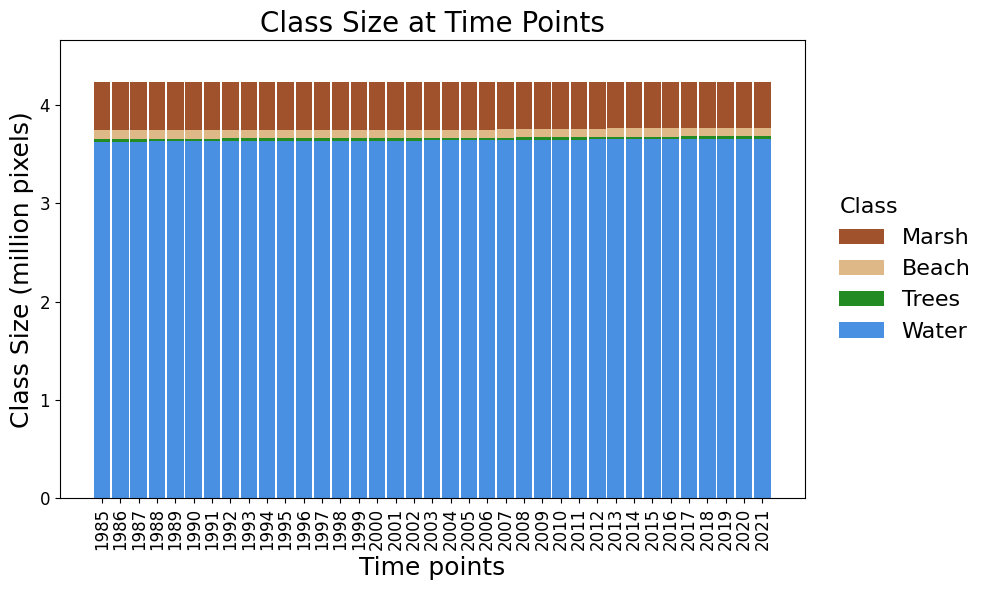

QuestEngine: ----------------------------------------------------------------------
The graphic sorts the land cover classes based on their overall net
size change. It places the class with the largest gain at the base
of the stacked bar. It positions the remaining classes sequentially
above it. Finally, it places the class experiencing the largest loss
at the very top of the stack.
----------------------------------------------------------------------

------------------------------------------------------------
You: quit


In [ ]:
# @title 4.1 QuestEngine Chat Interface
# @markdown Initializes the master agentic AI loop with access to ALL tools and explicit docstrings from all modules (Class Size, Number of Changes, Trajectories, Transition Matrices, Change Components, Maps).

# 1. Authentication and Initialization
if colab_auth is not None:
    try:
        colab_auth.authenticate_user()
    except Exception:
        pass

api_key = resolve_gemini_api_key() if "resolve_gemini_api_key" in globals() else os.getenv("GEMINI_API_KEY")
if api_key is not None:
    os.environ["GEMINI_API_KEY"] = api_key

if "GEMINI_API_KEY" not in os.environ:
    raise RuntimeError("GEMINI_API_KEY not available. Run Cell 6 first.")

# Initialize all analyzers
BUCKET_NAME = "ee-antoniovicgf-vcr-rasters-1985-2021"
analyzer_class = QuestClassSize(BUCKET_NAME)
analyzer_changes = QuestNumberChanges(BUCKET_NAME)
analyzer_traj = QuestTrajectory(BUCKET_NAME)
analyzer_trans = QuestTransition(BUCKET_NAME)
analyzer_comp = QuestChangeComponents(BUCKET_NAME)
analyzer_maps = QuestMaps(BUCKET_NAME)

# 2. Unified Tool Definitions with Explicit Docstrings

# --- Class Size Tools ---
def get_class_pixels_over_time() -> dict:
    """
    Retrieves pixel counts over time.
    """
    return analyzer_class.compute_class_pixels_over_time()

def plot_historical_class_sizes(specific_years: list[int] = None) -> str:
    """
    Plots the pixel counts over time, optionally filtered by specific years.

    Parameters
    ----------
    specific_years : list of int, optional
        A list of years to plot. If the user asks for a range (e.g., 1990 to 2000),
        expand it into a complete list of integers covering every year in that span.
    """
    return analyzer_class.plot_class_sizes(specific_years=specific_years)

# --- Number of Changes Tools ---
def get_number_of_changes_per_interval() -> dict:
    """
    Retrieves the number of changes per pixel grouped by time interval.
    """
    return analyzer_changes.compute_number_of_changes().to_dict()

def get_overall_number_of_changes() -> dict:
    """
    Retrieves the overall number of changes with absolute pixels and percentages.
    """
    return analyzer_changes.compute_overall_changes().to_dict(orient="index")

def plot_interval_changes_chart(start_year: int = None, end_year: int = None) -> str:
    """
    Plots a stacked bar chart showing the sequence of changes per time interval,
    optionally filtered by a custom year range.

    Parameters
    ----------
    start_year : int, optional
        The starting year for the filter (e.g., 1990).
    end_year : int, optional
        The ending year for the filter (e.g., 2020).
    """
    return analyzer_changes.plot_interval_changes(start_year=start_year, end_year=end_year)

def plot_overall_changes_chart(metric: str = "percentage") -> str:
    """
    Plots a stacked bar chart of the overall number of changes.

    Parameters
    ----------
    metric : str
        The metric for the Y-axis. Must be either 'percentage' or 'pixels'.
        Default is 'percentage'.
    """
    return analyzer_changes.plot_overall_changes(metric=metric)

def plot_custom_extent_overall_changes_chart(start_year: int, end_year: int, metric: str = "percentage") -> str:
    """
    Plots the overall changes chart for a custom time extent.

    Parameters
    ----------
    start_year : int
        The starting year of the time extent.
    end_year : int
        The ending year of the time extent.
    metric : str
        The metric for the Y-axis. Must be 'percentage' or 'pixels'.
    """
    custom_analyzer = QuestCustomExtentChanges(BUCKET_NAME, start_year=start_year, end_year=end_year)
    return custom_analyzer.plot_overall_changes(metric=metric)

# --- Trajectory Tools ---
def get_trajectory_per_interval() -> dict:
    """
    Retrieves the count of trajectory classes grouped by time interval.
    """
    return analyzer_traj.compute_trajectory_intervals().to_dict()

def get_overall_trajectories() -> dict:
    """
    Retrieves the overall trajectory distribution with absolute pixels and percentages.
    """
    return analyzer_traj.compute_overall_trajectories().to_dict(orient="index")

def plot_trajectory_interval_chart(start_year: int = None, end_year: int = None) -> str:
    """
    Plots a stacked bar chart showing trajectory classes per time interval,
    optionally filtered by a custom year range.
    """
    return analyzer_traj.plot_trajectory_intervals(start_year=start_year, end_year=end_year)

def plot_trajectory_overall_chart(metric: str = "percentage") -> str:
    """
    Plots a stacked bar chart of the overall trajectory distribution.
    Metric must be either 'percentage' or 'pixels'.
    """
    return analyzer_traj.plot_overall_trajectories(metric=metric)

def plot_custom_extent_overall_trajectory_chart(start_year: int, end_year: int, metric: str = "percentage") -> str:
    """
    Plots the overall trajectory distributions chart for a custom time extent.
    """
    custom_analyzer = QuestCustomExtentTrajectory(BUCKET_NAME, start_year=start_year, end_year=end_year)
    return custom_analyzer.plot_overall_trajectories(metric=metric)

# --- Transition Matrices Tools ---
def get_transition_matrix(matrix_key: str) -> dict:
    """
    Retrieves the numerical data for a specific transition matrix as a dictionary.
    Valid keys include: 'time_intervals', 'extent', 'allocation_exchange',
    'quantity_allocation_shift', 'alternation_exchange', 'alternation_shift',
    'indirect_extent', or specific intervals like 'interval_1990-2000'.
    """
    matrices = analyzer_trans.compute_transition_matrices()
    if matrix_key in matrices:
        return matrices[matrix_key].to_dict()
    return {"error": f"Matrix '{matrix_key}' not found."}

def plot_transition_heatmap(matrix_key: str) -> str:
    """
    Plots a heatmap for a specific transition matrix.
    Valid keys include: 'time_intervals', 'extent', 'allocation_exchange',
    'quantity_allocation_shift', 'alternation_exchange', 'alternation_shift',
    'indirect_extent', or specific intervals like 'interval_1990-2000'.
    """
    return analyzer_trans.plot_matrix_heatmap(matrix_key=matrix_key)

# --- Change Components Tools ---
def get_change_components_table() -> str:
    """
    Retrieves the standardized table of all calculated change components.
    Returns the data formatted as a CSV string.
    """
    return analyzer_comp.compute_change_components_table().to_csv(index=False)

def plot_intervals_components() -> str:
    """
    Plots the aggregated change components across individual time intervals.
    """
    return analyzer_comp.plot_change_components_intervals()

def plot_overall_components() -> str:
    """
    Plots the overall change components as a single stacked bar.
    """
    return analyzer_comp.plot_change_components_overall()

def plot_class_components() -> str:
    """
    Plots per-class gains and losses of change components as stacked bars.
    """
    return analyzer_comp.plot_change_components_by_class()

# --- Maps Tools ---
def plot_number_of_changes_spatial_map() -> str:
    """
    Generates and displays the Number of Changes spatial map.
    """
    return analyzer_maps.plot_number_of_changes_map()

def plot_trajectory_spatial_map() -> str:
    """
    Generates and displays the Trajectories spatial map.
    """
    return analyzer_maps.plot_trajectory_map()


# 3. Unified Tool List
all_tools = [
    get_class_pixels_over_time,
    plot_historical_class_sizes,
    get_number_of_changes_per_interval,
    get_overall_number_of_changes,
    plot_interval_changes_chart,
    plot_overall_changes_chart,
    plot_custom_extent_overall_changes_chart,
    get_trajectory_per_interval,
    get_overall_trajectories,
    plot_trajectory_interval_chart,
    plot_trajectory_overall_chart,
    plot_custom_extent_overall_trajectory_chart,
    get_transition_matrix,
    plot_transition_heatmap,
    get_change_components_table,
    plot_intervals_components,
    plot_overall_components,
    plot_class_components,
    plot_number_of_changes_spatial_map,
    plot_trajectory_spatial_map,
]

# 4. Agent Configuration
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

chat = client.chats.create(
    model="gemini-2.5-flash",
    config=types.GenerateContentConfig(
        tools=all_tools,
        temperature=0.1,
        system_instruction=(
            "You are QuestEngine, a specialized geospatial analyst strictly "
            "confined to the QUEST methodology. Your absolute rule is to "
            "only answer questions related to the provided land cover "
            "change data. If the user asks about anything else, you must "
            "refuse to answer and state clearly that your scope is limited "
            "to QUEST spatial analysis. You have access to a full suite of tools "
            "to retrieve raw data and plot charts/maps for Class Size, Number of Changes, "
            "Trajectories, Transition Matrices, and Change Components. Answer the user's "
            "questions by deciding which tool(s) are appropriate.\n\n"
            "CRITICAL FORMATTING RULE: When a tool returns a text enclosed in dashed lines "
            "(---) with specific line breaks (\\n), YOU MUST OUTPUT THAT EXACT STRING directly "
            "to the user. You are explicitly forbidden from summarizing it, removing newlines, "
            "or rewriting it as a single line."
        ),
    )
)

# 5. Continuous Chat Interface
print(
    "Hello! I am QuestEngine, your friendly agentic AI for spatial analysis.\n"
    "I'm here to help you explore your land cover data using the QUEST methodology.\n\n"
    "If you are not sure where to start, I suggest this step-by-step workflow:\n"
    " 1. Explore the time series of your input raster maps (ask about class sizes/extents over time).\n"
    " 2. Look into the Number of Changes and Trajectories to see pixel-level dynamics.\n"
    " 3. Dive into the Transition Matrices and Change Components for detailed mechanics of change.\n\n"
    "Feel free to ask for data, graphics, or maps whenever you're ready!\n"
    "(Type 'quit' to exit)\n" +
    "-" * 60
)

while True:
    question = input("You: ")

    if question.lower() == 'quit':
        break

    if not question.strip():
        continue

    try:
        answer = chat.send_message(question)
        print(f"QuestEngine: {answer.text}")
        print("-" * 60)
        time.sleep(4)
    except Exception as e:
        print(f"QuestEngine Error: {e}")
        print("-" * 60)
        time.sleep(4)
